In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
Train=pd.read_csv("/content/drive/MyDrive/Medicare_Fraud/Train-1542865627584.csv")
Train_Beneficiarydata=pd.read_csv("/content/drive/MyDrive/Medicare_Fraud/Train_Beneficiarydata-1542865627584.csv")
Train_Inpatientdata=pd.read_csv("/content/drive/MyDrive/Medicare_Fraud/Train_Inpatientdata-1542865627584.csv")
Train_Outpatientdata=pd.read_csv("/content/drive/MyDrive/Medicare_Fraud/Train_Outpatientdata-1542865627584.csv")

# Load Test Dataset

Test=pd.read_csv("/content/drive/MyDrive/Medicare_Fraud/Test-1542969243754.csv")
Test_Beneficiarydata=pd.read_csv("/content/drive/MyDrive/Medicare_Fraud/Test_Beneficiarydata-1542969243754.csv")
Test_Inpatientdata=pd.read_csv("/content/drive/MyDrive/Medicare_Fraud/Test_Inpatientdata-1542969243754.csv")
Test_Outpatientdata=pd.read_csv("/content/drive/MyDrive/Medicare_Fraud/Test_Outpatientdata-1542969243754.csv")

In [4]:
datasets = {
    "Train": Train,
    "Train Beneficiary": Train_Beneficiarydata,
    "Train Inpatient": Train_Inpatientdata,
    "Train Outpatient": Train_Outpatientdata,
    "Test": Test,
    "Test Beneficiary": Test_Beneficiarydata,
    "Test Inpatient": Test_Inpatientdata,
    "Test Outpatient": Test_Outpatientdata
}

for name, df in datasets.items():
    print(f"{name:20} → Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

Train                → Rows: 5,410 | Columns: 2
Train Beneficiary    → Rows: 138,556 | Columns: 25
Train Inpatient      → Rows: 40,474 | Columns: 30
Train Outpatient     → Rows: 517,737 | Columns: 27
Test                 → Rows: 1,353 | Columns: 1
Test Beneficiary     → Rows: 63,968 | Columns: 25
Test Inpatient       → Rows: 9,551 | Columns: 30
Test Outpatient      → Rows: 125,841 | Columns: 27


In [5]:
for name, df in datasets.items():
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print(df.columns.tolist())


Train
['Provider', 'PotentialFraud']

Train Beneficiary
['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']

Train Inpatient
['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDia

In [6]:
for name, df in datasets.items():
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print(df.dtypes)


Train
Provider          object
PotentialFraud    object
dtype: object

Train Beneficiary
BeneID                             object
DOB                                object
DOD                                object
Gender                              int64
Race                                int64
RenalDiseaseIndicator              object
State                               int64
County                              int64
NoOfMonths_PartACov                 int64
NoOfMonths_PartBCov                 int64
ChronicCond_Alzheimer               int64
ChronicCond_Heartfailure            int64
ChronicCond_KidneyDisease           int64
ChronicCond_Cancer                  int64
ChronicCond_ObstrPulmonary          int64
ChronicCond_Depression              int64
ChronicCond_Diabetes                int64
ChronicCond_IschemicHeart           int64
ChronicCond_Osteoporasis            int64
ChronicCond_rheumatoidarthritis     int64
ChronicCond_stroke                  int64
IPAnnualReimbursementAmt    

In [7]:
# Step 2 — Missing Value Analysis #
# Purpose #
# This cell checks all training and testing datasets for missing values before data preprocessing and feature engineering. #
# What This Cell Does #
# - Iterates through every dataset stored in the `datasets` dictionary. #
# - Calculates the total number of missing values in each column using `isnull().sum()`. #
# - Calculates the percentage of missing values in each column. #
# - Creates a summary table containing `Missing_Count` and `Missing_Percentage`. #
# - Displays only the columns that contain missing values. #
# Python Code Explanation #
# `for name, df in datasets.items():` iterates through every dataset in the dictionary. `name` stores the dataset name and `df` stores the corresponding DataFrame. #
# `df.isnull()` checks every cell for missing values and returns Boolean values. #
# `.sum()` counts the missing values for each column. #
# `len(df)` returns the total number of rows in the current DataFrame. #
# `(missing / len(df) * 100)` calculates the percentage of missing values in each column. #
# `.round(2)` rounds the calculated percentages to two decimal places. #
# `pd.DataFrame({...})` creates a new DataFrame containing the missing-value count and percentage. #
# `missing_table["Missing_Count"] > 0` creates a condition that identifies columns containing at least one missing value. #
# `missing_table[...]` filters the table and displays only columns with missing values. #
# Why This Is Needed #
# Missing values can affect data integration, feature engineering, statistical calculations, machine learning model training, and prediction reliability. #
# Therefore, missing values are identified before the datasets are combined and used for feature engineering and machine learning. #
# Output #
# For each dataset, the cell displays the columns containing missing values together with their missing-value count and percentage. #
# If no rows are displayed for a dataset, it means that the dataset contains no missing values. #
for name, df in datasets.items():
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)

    missing_table = pd.DataFrame({
        "Missing_Count": missing,
        "Missing_Percentage": missing_pct
    })

    print(missing_table[missing_table["Missing_Count"] > 0])


Train
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []

Train Beneficiary
     Missing_Count  Missing_Percentage
DOD         137135               98.97

Train Inpatient
                     Missing_Count  Missing_Percentage
AttendingPhysician             112                0.28
OperatingPhysician           16644               41.12
OtherPhysician               35784               88.41
DeductibleAmtPaid              899                2.22
ClmDiagnosisCode_2             226                0.56
ClmDiagnosisCode_3             676                1.67
ClmDiagnosisCode_4            1534                3.79
ClmDiagnosisCode_5            2894                7.15
ClmDiagnosisCode_6            4838               11.95
ClmDiagnosisCode_7            7258               17.93
ClmDiagnosisCode_8            9942               24.56
ClmDiagnosisCode_9           13497               33.35
ClmDiagnosisCode_10          36547               90.30
ClmProcedureCode_1           17326    

In [8]:
print("PotentialFraud Distribution")
print("=" * 50)

print(Train["PotentialFraud"].value_counts())

print("\nPercentage:")
print((Train["PotentialFraud"].value_counts(normalize=True) * 100).round(2))

PotentialFraud Distribution
PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

Percentage:
PotentialFraud
No     90.65
Yes     9.35
Name: proportion, dtype: float64


In [ ]:
print("Unique PotentialFraud values:")
print(Train["PotentialFraud"].unique())

print("\nUnique Provider IDs:")
print("Train:", Train["Provider"].nunique())
print("Test :", Test["Provider"].nunique())

print("\nTrain Provider duplicates:", Train["Provider"].duplicated().sum())
print("Test Provider duplicates :", Test["Provider"].duplicated().sum())

Unique PotentialFraud values:
['No' 'Yes']

Unique Provider IDs:
Train: 5410
Test : 1353

Train Provider duplicates: 0
Test Provider duplicates : 0


In [9]:
# Step 3 — Train-Test Provider Overlap Validation #
# Purpose #
# This cell verifies that the providers in the training dataset and testing dataset are completely separated. #
# What This Cell Does #
# - Extracts all unique provider IDs from the training dataset. #
# - Extracts all unique provider IDs from the testing dataset. #
# - Finds providers that occur in both datasets. #
# - Reports the number of providers in each dataset and the number of overlapping providers. #
# Python Code Explanation #
# `set(Train["Provider"])` converts the Provider column into a Python set containing only unique training provider IDs. #
# `set(Test["Provider"])` converts the Provider column into a Python set containing only unique testing provider IDs. #
# `.intersection()` finds the provider IDs that are present in both the training and testing sets. #
# `len()` returns the number of unique providers or overlapping providers. #
# `if len(overlap) > 0:` checks whether at least one provider exists in both datasets. #
# `print()` displays the validation results and warning messages. #
# `list(overlap)[:20]` converts the overlapping provider set into a list and displays up to the first 20 overlapping provider IDs. #
# `else:` executes when there are no overlapping providers. #
# Why This Is Needed #
# Provider-level separation is important because the fraud detection model is designed to learn provider behavior from the training data and evaluate it on unseen providers in the validation/test data. #
# If the same provider appears in both datasets, provider-level information could leak from training into evaluation and produce overly optimistic model performance. #
# This check therefore helps verify that the provider split is appropriate for leakage-free evaluation. #
# Output #
# The cell reports the number of unique training providers, the number of unique testing providers, and the number of providers appearing in both datasets. #
# If the overlap count is zero, the output confirms that there is no provider overlap between Train and Test. #
# If the overlap count is greater than zero, the cell displays a warning and up to 20 overlapping provider IDs. #
train_providers = set(Train["Provider"])
test_providers = set(Test["Provider"])

overlap = train_providers.intersection(test_providers)

print("Train providers :", len(train_providers))
print("Test providers  :", len(test_providers))
print("Overlapping providers:", len(overlap))

if len(overlap) > 0:
    print("\nWarning: Some providers appear in both Train and Test.")
    print(list(overlap)[:20])
else:
    print("\nNo provider overlap between Train and Test.")

Train providers : 5410
Test providers  : 1353
Overlapping providers: 0

No provider overlap between Train and Test.


In [10]:
print("TRAIN RELATIONSHIP CHECK")
print("=" * 60)

print("\nUnique BeneID")
print("Beneficiary :", Train_Beneficiarydata["BeneID"].nunique())
print("Inpatient   :", Train_Inpatientdata["BeneID"].nunique())
print("Outpatient  :", Train_Outpatientdata["BeneID"].nunique())

print("\nUnique Provider")
print("Provider label :", Train["Provider"].nunique())
print("Inpatient      :", Train_Inpatientdata["Provider"].nunique())
print("Outpatient     :", Train_Outpatientdata["Provider"].nunique())

print("\nUnique ClaimID")
print("Inpatient  :", Train_Inpatientdata["ClaimID"].nunique())
print("Outpatient :", Train_Outpatientdata["ClaimID"].nunique())

TRAIN RELATIONSHIP CHECK

Unique BeneID
Beneficiary : 138556
Inpatient   : 31289
Outpatient  : 133980

Unique Provider
Provider label : 5410
Inpatient      : 2092
Outpatient     : 5012

Unique ClaimID
Inpatient  : 40474
Outpatient : 517737


In [ ]:
inpatient_claims = set(Train_Inpatientdata["ClaimID"])
outpatient_claims = set(Train_Outpatientdata["ClaimID"])

claim_overlap = inpatient_claims.intersection(outpatient_claims)

print("Inpatient claims :", len(inpatient_claims))
print("Outpatient claims:", len(outpatient_claims))
print("Overlapping ClaimIDs:", len(claim_overlap))

if len(claim_overlap) > 0:
    print("\nOverlapping ClaimIDs:")
    print(list(claim_overlap)[:20])
else:
    print("\nNo ClaimID overlap between Inpatient and Outpatient.")

Inpatient claims : 40474
Outpatient claims: 517737
Overlapping ClaimIDs: 0

No ClaimID overlap between Inpatient and Outpatient.


In [11]:
# Step 4 — Beneficiary and Provider Relationship Validation #
# Purpose #
# This cell validates the relationships between beneficiaries, providers, and claims across the training datasets before performing data integration and feature engineering. #
# What This Cell Does #
# - Checks whether every beneficiary appearing in inpatient claims also exists in the training beneficiary table. #
# - Checks whether every beneficiary appearing in outpatient claims also exists in the training beneficiary table. #
# - Checks whether every provider appearing in inpatient claims also exists in the training provider-label table. #
# - Checks whether every provider appearing in outpatient claims also exists in the training provider-label table. #
# Python Code Explanation #
# `set(Train_Beneficiarydata["BeneID"])` converts the beneficiary ID column into a Python set containing unique beneficiary IDs from the beneficiary table. #
# `set(Train_Inpatientdata["BeneID"])` creates a set containing unique beneficiaries appearing in inpatient claims. #
# `set(Train_Outpatientdata["BeneID"])` creates a set containing unique beneficiaries appearing in outpatient claims. #
# `inpatient_bene_ids - train_bene_ids` performs Python set difference and identifies inpatient beneficiaries that are missing from the beneficiary table. #
# `outpatient_bene_ids - train_bene_ids` identifies outpatient beneficiaries that are missing from the beneficiary table. #
# `len()` counts the number of unmatched beneficiary IDs. #
# `set(Train["Provider"])` creates a set of unique providers contained in the training provider-label table. #
# `set(Train_Inpatientdata["Provider"])` creates a set of providers appearing in inpatient claims. #
# `set(Train_Outpatientdata["Provider"])` creates a set of providers appearing in outpatient claims. #
# `inpatient_provider_ids - train_provider_ids` identifies inpatient providers that do not have a corresponding provider entry in the training label table. #
# `outpatient_provider_ids - train_provider_ids` identifies outpatient providers that do not have a corresponding provider entry in the training label table. #
# `print()` displays the validation results for both beneficiary and provider matching. #
# Why This Is Needed #
# The project combines multiple related datasets using common identifiers such as `BeneID` and `Provider`. #
# These checks verify that the identifiers required for later merging are properly represented across the related datasets. #
# Missing beneficiary or provider relationships could result in unmatched records, missing values after merging, or incorrect provider-level and claim-level feature calculations. #
# Output #
# The cell reports the number of inpatient and outpatient beneficiaries that cannot be found in the beneficiary table. #
# It also reports the number of inpatient and outpatient providers that cannot be found in the training provider-label table. #
# A value of zero indicates that all identifiers from the corresponding claims dataset have a matching entry in the reference table. #
print("BENEFICIARY MATCH CHECK")
print("=" * 60)

train_bene_ids = set(Train_Beneficiarydata["BeneID"])

inpatient_bene_ids = set(Train_Inpatientdata["BeneID"])
outpatient_bene_ids = set(Train_Outpatientdata["BeneID"])

missing_inpatient_bene = inpatient_bene_ids - train_bene_ids
missing_outpatient_bene = outpatient_bene_ids - train_bene_ids

print("Inpatient BeneIDs not in Beneficiary table:",
      len(missing_inpatient_bene))

print("Outpatient BeneIDs not in Beneficiary table:",
      len(missing_outpatient_bene))


print("\nPROVIDER MATCH CHECK")
print("=" * 60)

train_provider_ids = set(Train["Provider"])

inpatient_provider_ids = set(Train_Inpatientdata["Provider"])
outpatient_provider_ids = set(Train_Outpatientdata["Provider"])

missing_inpatient_provider = inpatient_provider_ids - train_provider_ids
missing_outpatient_provider = outpatient_provider_ids - train_provider_ids

print("Inpatient Providers not in Train label:",
      len(missing_inpatient_provider))

print("Outpatient Providers not in Train label:",
      len(missing_outpatient_provider))

BENEFICIARY MATCH CHECK
Inpatient BeneIDs not in Beneficiary table: 0
Outpatient BeneIDs not in Beneficiary table: 0

PROVIDER MATCH CHECK
Inpatient Providers not in Train label: 0
Outpatient Providers not in Train label: 0


In [12]:
# Step 5 — Unified Inpatient and Outpatient Claims Dataset #
# Purpose #
# This cell combines the separate inpatient and outpatient claim datasets into a single unified claim-level dataset for downstream analysis and feature engineering. #
# What This Cell Does #
# - Creates independent copies of the inpatient and outpatient training datasets. #
# - Adds a `ClaimType` column to identify whether each claim is inpatient or outpatient. #
# - Combines both datasets into one DataFrame. #
# - Checks the resulting dataset shape. #
# - Checks the distribution of inpatient and outpatient claims. #
# - Verifies the number of unique ClaimIDs. #
# Python Code Explanation #
# `Train_Inpatientdata.copy()` creates a separate copy of the inpatient DataFrame so that modifications do not alter the original dataset. #
# `Train_Outpatientdata.copy()` creates a separate copy of the outpatient DataFrame. #
# `inpatient["ClaimType"] = "Inpatient"` creates a new column and assigns the value `Inpatient` to every inpatient claim. #
# `outpatient["ClaimType"] = "Outpatient"` creates the same column for outpatient claims and assigns `Outpatient` to every row. #
# `pd.concat([inpatient, outpatient], ignore_index=True, sort=False)` vertically combines the two DataFrames into one dataset. #
# `ignore_index=True` creates a new continuous row index after concatenation instead of preserving the original indexes. #
# `sort=False` prevents pandas from alphabetically sorting the columns during concatenation and preserves the existing column order as much as possible. #
# `unified_claims.shape` returns the number of rows and columns in the combined claim dataset. #
# `unified_claims["ClaimType"].value_counts()` counts how many claims belong to each claim type. #
# `unified_claims["ClaimID"].nunique()` counts the number of unique claims using the `ClaimID` column. #
# Why This Is Needed #
# Inpatient and outpatient claims are stored in separate source tables but represent the two major claim types that need to be analyzed together. #
# Creating a unified claim table provides a consistent structure for claim-level feature engineering, provider-level aggregation, anomaly detection, and later fraud, waste, and abuse analysis. #
# The `ClaimType` column preserves the distinction between inpatient and outpatient claims after they are combined. #
# Output #
# The cell reports the shape of the unified claim dataset, the number of inpatient and outpatient claims, and the number of unique ClaimIDs. #
# These checks help confirm that both claim sources were successfully combined and that claims can be uniquely identified for subsequent analysis. #
inpatient = Train_Inpatientdata.copy()
outpatient = Train_Outpatientdata.copy()

inpatient["ClaimType"] = "Inpatient"
outpatient["ClaimType"] = "Outpatient"

unified_claims = pd.concat(
    [inpatient, outpatient],
    ignore_index=True,
    sort=False
)

print("Unified claims shape:", unified_claims.shape)

print("\nClaim type distribution:")
print(unified_claims["ClaimType"].value_counts())

print("\nUnique ClaimIDs:", unified_claims["ClaimID"].nunique())

Unified claims shape: (558211, 31)

Claim type distribution:
ClaimType
Outpatient    517737
Inpatient      40474
Name: count, dtype: int64

Unique ClaimIDs: 558211


In [13]:
print("Unified Claims Columns:")
print("=" * 80)

for i, col in enumerate(unified_claims.columns, start=1):
    print(f"{i:2}. {col}")

Unified Claims Columns:
 1. BeneID
 2. ClaimID
 3. ClaimStartDt
 4. ClaimEndDt
 5. Provider
 6. InscClaimAmtReimbursed
 7. AttendingPhysician
 8. OperatingPhysician
 9. OtherPhysician
10. AdmissionDt
11. ClmAdmitDiagnosisCode
12. DeductibleAmtPaid
13. DischargeDt
14. DiagnosisGroupCode
15. ClmDiagnosisCode_1
16. ClmDiagnosisCode_2
17. ClmDiagnosisCode_3
18. ClmDiagnosisCode_4
19. ClmDiagnosisCode_5
20. ClmDiagnosisCode_6
21. ClmDiagnosisCode_7
22. ClmDiagnosisCode_8
23. ClmDiagnosisCode_9
24. ClmDiagnosisCode_10
25. ClmProcedureCode_1
26. ClmProcedureCode_2
27. ClmProcedureCode_3
28. ClmProcedureCode_4
29. ClmProcedureCode_5
30. ClmProcedureCode_6
31. ClaimType


In [14]:
print("Beneficiary rows:", len(Train_Beneficiarydata))
print("Unique BeneID:", Train_Beneficiarydata["BeneID"].nunique())
print("Duplicate BeneID:", Train_Beneficiarydata["BeneID"].duplicated().sum())

Beneficiary rows: 138556
Unique BeneID: 138556
Duplicate BeneID: 0


In [15]:
# Step 6 — Beneficiary Data Integration #
# Purpose: Merge beneficiary information into the unified claims dataset using `BeneID`. #
# Code: Selects required beneficiary columns, performs a left merge, and validates the many-to-one relationship. #
# Why: Adds beneficiary attributes such as DOB, demographics, coverage, and chronic conditions for feature engineering. #
# Validation: Checks the dataset shape and unique ClaimIDs after merging to ensure claims were not duplicated. #
beneficiary_cols = [
    "BeneID",
    "DOB",
    "DOD",
    "Gender",
    "Race",
    "RenalDiseaseIndicator",
    "State",
    "County",
    "NoOfMonths_PartACov",
    "NoOfMonths_PartBCov",
    "ChronicCond_Alzheimer",
    "ChronicCond_Heartfailure",
    "ChronicCond_KidneyDisease",
    "ChronicCond_Cancer",
    "ChronicCond_ObstrPulmonary",
    "ChronicCond_Depression",
    "ChronicCond_Diabetes",
    "ChronicCond_IschemicHeart",
    "ChronicCond_Osteoporasis",
    "ChronicCond_rheumatoidarthritis",
    "ChronicCond_stroke",
    "IPAnnualReimbursementAmt",
    "IPAnnualDeductibleAmt",
    "OPAnnualReimbursementAmt",
    "OPAnnualDeductibleAmt"
]

unified_claims = unified_claims.merge(
    Train_Beneficiarydata[beneficiary_cols],
    on="BeneID",
    how="left",
    validate="many_to_one"
)

print("Shape after beneficiary merge:", unified_claims.shape)
print("Unique ClaimIDs:", unified_claims["ClaimID"].nunique())

Shape after beneficiary merge: (558211, 55)
Unique ClaimIDs: 558211


In [16]:
beneficiary_check_cols = [
    "DOB",
    "Gender",
    "Race",
    "State",
    "NoOfMonths_PartACov",
    "NoOfMonths_PartBCov"
]

print("Missing values after beneficiary merge")
print("=" * 60)

print(unified_claims[beneficiary_check_cols].isnull().sum())

Missing values after beneficiary merge
DOB                    0
Gender                 0
Race                   0
State                  0
NoOfMonths_PartACov    0
NoOfMonths_PartBCov    0
dtype: int64


In [17]:
print("Duplicate ClaimID check")
print("=" * 50)

duplicate_claims = unified_claims["ClaimID"].duplicated().sum()

print("Duplicate ClaimIDs:", duplicate_claims)

if duplicate_claims == 0:
    print("✓ Every ClaimID is unique")
else:
    print("⚠ Duplicate ClaimIDs found")

Duplicate ClaimID check
Duplicate ClaimIDs: 0
✓ Every ClaimID is unique


In [18]:
date_columns = [
    "DOB",
    "DOD",
    "ClaimStartDt",
    "ClaimEndDt",
    "AdmissionDt",
    "DischargeDt"
]

print("Date columns:")
for col in date_columns:
    print(f"{col}: {unified_claims[col].dtype}")

Date columns:
DOB: object
DOD: object
ClaimStartDt: object
ClaimEndDt: object
AdmissionDt: object
DischargeDt: object


In [19]:
date_columns = [
    "DOB",
    "DOD",
    "ClaimStartDt",
    "ClaimEndDt",
    "AdmissionDt",
    "DischargeDt"
]

for col in date_columns:
    unified_claims[col] = pd.to_datetime(
        unified_claims[col],
        errors="coerce"
    )

print(unified_claims[date_columns].dtypes)

DOB             datetime64[ns]
DOD             datetime64[ns]
ClaimStartDt    datetime64[ns]
ClaimEndDt      datetime64[ns]
AdmissionDt     datetime64[ns]
DischargeDt     datetime64[ns]
dtype: object


In [20]:
print("Missing dates after conversion")
print("=" * 60)

for col in date_columns:
    missing = unified_claims[col].isna().sum()
    percentage = (missing / len(unified_claims) * 100)

    print(f"{col:20} → {missing:,} missing ({percentage:.2f}%)")

Missing dates after conversion
DOB                  → 0 missing (0.00%)
DOD                  → 554,080 missing (99.26%)
ClaimStartDt         → 0 missing (0.00%)
ClaimEndDt           → 0 missing (0.00%)
AdmissionDt          → 517,737 missing (92.75%)
DischargeDt          → 517,737 missing (92.75%)


In [21]:
print("Admission/Discharge date availability by ClaimType")
print("=" * 70)

date_check = unified_claims.groupby("ClaimType").agg(
    Total_Claims=("ClaimID", "count"),
    Missing_AdmissionDt=("AdmissionDt", lambda x: x.isna().sum()),
    Missing_DischargeDt=("DischargeDt", lambda x: x.isna().sum())
)

print(date_check)

Admission/Discharge date availability by ClaimType
            Total_Claims  Missing_AdmissionDt  Missing_DischargeDt
ClaimType                                                         
Inpatient          40474                    0                    0
Outpatient        517737               517737               517737


In [22]:
unified_claims["ClaimDurationDays"] = (
    unified_claims["ClaimEndDt"] - unified_claims["ClaimStartDt"]
).dt.days

unified_claims["ClaimStartYear"] = unified_claims["ClaimStartDt"].dt.year
unified_claims["ClaimStartMonth"] = unified_claims["ClaimStartDt"].dt.month
unified_claims["ClaimStartDayOfWeek"] = unified_claims["ClaimStartDt"].dt.dayofweek

print(
    unified_claims[
        [
            "ClaimID",
            "ClaimType",
            "ClaimDurationDays",
            "ClaimStartYear",
            "ClaimStartMonth",
            "ClaimStartDayOfWeek"
        ]
    ].head()
)

    ClaimID  ClaimType  ClaimDurationDays  ClaimStartYear  ClaimStartMonth  \
0  CLM46614  Inpatient                  6            2009                4   
1  CLM66048  Inpatient                  2            2009                8   
2  CLM68358  Inpatient                  3            2009                9   
3  CLM38412  Inpatient                  8            2009                2   
4  CLM63689  Inpatient                 17            2009                8   

   ClaimStartDayOfWeek  
0                    6  
1                    0  
2                    3  
3                    5  
4                    3  


In [23]:
print("Claim Duration Check")
print("=" * 60)

print("Minimum duration:", unified_claims["ClaimDurationDays"].min())
print("Maximum duration:", unified_claims["ClaimDurationDays"].max())
print("Negative durations:",
      (unified_claims["ClaimDurationDays"] < 0).sum())
print("Missing durations:",
      unified_claims["ClaimDurationDays"].isna().sum())

print("\nDuration statistics:")
print(unified_claims["ClaimDurationDays"].describe())

Claim Duration Check
Minimum duration: 0
Maximum duration: 36
Negative durations: 0
Missing durations: 0

Duration statistics:
count    558211.000000
mean          1.727940
std           4.904984
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          36.000000
Name: ClaimDurationDays, dtype: float64


In [24]:
unified_claims["BeneficiaryAge"] = (
    (unified_claims["ClaimStartDt"] - unified_claims["DOB"]).dt.days / 365.25
)

unified_claims["BeneficiaryAge"] = unified_claims["BeneficiaryAge"].round(1)

print(
    unified_claims[
        ["ClaimID", "BeneID", "DOB", "ClaimStartDt", "BeneficiaryAge"]
    ].head(10)
)

    ClaimID     BeneID        DOB ClaimStartDt  BeneficiaryAge
0  CLM46614  BENE11001 1943-01-01   2009-04-12            66.3
1  CLM66048  BENE11001 1943-01-01   2009-08-31            66.7
2  CLM68358  BENE11001 1943-01-01   2009-09-17            66.7
3  CLM38412  BENE11011 1914-03-01   2009-02-14            95.0
4  CLM63689  BENE11014 1938-04-01   2009-08-13            71.4
5  CLM70950  BENE11017 1940-06-01   2009-10-06            69.3
6  CLM32075  BENE11018 1939-10-01   2009-01-02            69.3
7  CLM62376  BENE11028 1941-12-01   2009-08-03            67.7
8  CLM62784  BENE11031 1944-12-01   2009-08-06            64.7
9  CLM31519  BENE11034 1946-03-01   2008-12-29            62.8


In [25]:
print("Beneficiary Age Check")
print("=" * 60)

print("Minimum age:", unified_claims["BeneficiaryAge"].min())
print("Maximum age:", unified_claims["BeneficiaryAge"].max())
print("Missing ages:", unified_claims["BeneficiaryAge"].isna().sum())

print("\nAge statistics:")
print(unified_claims["BeneficiaryAge"].describe())

Beneficiary Age Check
Minimum age: 25.1
Maximum age: 101.0
Missing ages: 0

Age statistics:
count    558211.000000
mean         73.297664
std          13.017340
min          25.100000
25%          67.500000
50%          74.200000
75%          82.000000
max         101.000000
Name: BeneficiaryAge, dtype: float64


In [26]:
chronic_cols = [
    "ChronicCond_Alzheimer",
    "ChronicCond_Heartfailure",
    "ChronicCond_KidneyDisease",
    "ChronicCond_Cancer",
    "ChronicCond_ObstrPulmonary",
    "ChronicCond_Depression",
    "ChronicCond_Diabetes",
    "ChronicCond_IschemicHeart",
    "ChronicCond_Osteoporasis",
    "ChronicCond_rheumatoidarthritis",
    "ChronicCond_stroke"
]

unified_claims["ChronicConditionCount"] = unified_claims[chronic_cols].sum(axis=1)

print(
    unified_claims[
        ["ClaimID", "BeneID", "ChronicConditionCount"]
    ].head(10)
)

    ClaimID     BeneID  ChronicConditionCount
0  CLM46614  BENE11001                     15
1  CLM66048  BENE11001                     15
2  CLM68358  BENE11001                     15
3  CLM38412  BENE11011                     16
4  CLM63689  BENE11014                     17
5  CLM70950  BENE11017                     13
6  CLM32075  BENE11018                     16
7  CLM62376  BENE11028                     19
8  CLM62784  BENE11031                     18
9  CLM31519  BENE11034                     13


In [27]:
# Step 7 — Chronic Condition Value Validation #
# Purpose: Check the unique values present in all chronic-condition columns. #
# Code: Iterates through `chronic_cols`, removes missing values using `dropna()`, gets unique values using `unique()`, converts them to a list, and sorts them using `sorted()`. #
# Why: Verifies that chronic-condition columns contain expected categorical values before feature engineering. #
# Output: Displays each chronic-condition column and its sorted unique non-missing values. #
print("Unique values in chronic-condition columns")
print("=" * 70)

for col in chronic_cols:
    print(f"{col:35} → {sorted(unified_claims[col].dropna().unique().tolist())}")

Unique values in chronic-condition columns
ChronicCond_Alzheimer               → [1, 2]
ChronicCond_Heartfailure            → [1, 2]
ChronicCond_KidneyDisease           → [1, 2]
ChronicCond_Cancer                  → [1, 2]
ChronicCond_ObstrPulmonary          → [1, 2]
ChronicCond_Depression              → [1, 2]
ChronicCond_Diabetes                → [1, 2]
ChronicCond_IschemicHeart           → [1, 2]
ChronicCond_Osteoporasis            → [1, 2]
ChronicCond_rheumatoidarthritis     → [1, 2]
ChronicCond_stroke                  → [1, 2]


In [28]:
# Step 8 — Chronic Condition Count #
# Purpose: Calculate the total number of chronic conditions associated with each beneficiary for every claim. #
# Code: Compares each chronic-condition column with the value `2`, where `2` represents the presence of the condition in the dataset. #
# `.sum(axis=1)` counts the number of chronic conditions present across each row (beneficiary/claim). #
# Why: Converts multiple chronic-condition indicators into one numerical `ChronicConditionCount` feature for claim-level and provider-level analysis. #
# Output: Displays the ClaimID, BeneID, and calculated ChronicConditionCount for the first 10 claims. #
unified_claims["ChronicConditionCount"] = (
    unified_claims[chronic_cols] == 2
).sum(axis=1)

print(
    unified_claims[
        ["ClaimID", "BeneID", "ChronicConditionCount"]
    ].head(10)
)

    ClaimID     BeneID  ChronicConditionCount
0  CLM46614  BENE11001                      4
1  CLM66048  BENE11001                      4
2  CLM68358  BENE11001                      4
3  CLM38412  BENE11011                      5
4  CLM63689  BENE11014                      6
5  CLM70950  BENE11017                      2
6  CLM32075  BENE11018                      5
7  CLM62376  BENE11028                      8
8  CLM62784  BENE11031                      7
9  CLM31519  BENE11034                      2


In [29]:
# Step 9 — Chronic Condition Count Validation #
# Purpose: Validate the calculated `ChronicConditionCount` feature. #
# Code: `.min()` finds the minimum chronic-condition count, `.max()` finds the maximum, and `.isna().sum()` counts missing values. #
# `value_counts()` calculates the frequency of each chronic-condition count, while `.sort_index()` displays the distribution in numerical order. #
# Why: Confirms that the feature has valid values, contains no unexpected missing values, and has a reasonable distribution before further feature engineering. #
# Output: Displays the minimum, maximum, missing-value count, and frequency distribution of `ChronicConditionCount`. #
print("Chronic Condition Count Check")
print("=" * 60)

print("Minimum:", unified_claims["ChronicConditionCount"].min())
print("Maximum:", unified_claims["ChronicConditionCount"].max())
print("Missing:", unified_claims["ChronicConditionCount"].isna().sum())

print("\nDistribution:")
print(unified_claims["ChronicConditionCount"].value_counts().sort_index())

Chronic Condition Count Check
Minimum: 0
Maximum: 11
Missing: 0

Distribution:
ChronicConditionCount
0       462
1      4190
2     17222
3     37887
4     60175
5     76516
6     82698
7     83461
8     72362
9     60015
10    41330
11    21893
Name: count, dtype: int64


In [30]:
print("Financial feature check")
print("=" * 60)

print("Reimbursement:")
print(unified_claims["InscClaimAmtReimbursed"].describe())

print("\nDeductible:")
print(unified_claims["DeductibleAmtPaid"].describe())

print("\nNegative reimbursement:",
      (unified_claims["InscClaimAmtReimbursed"] < 0).sum())

print("Negative deductible:",
      (unified_claims["DeductibleAmtPaid"] < 0).sum())

print("Missing reimbursement:",
      unified_claims["InscClaimAmtReimbursed"].isna().sum())

print("Missing deductible:",
      unified_claims["DeductibleAmtPaid"].isna().sum())

Financial feature check
Reimbursement:
count    558211.000000
mean        997.012133
std        3821.534891
min           0.000000
25%          40.000000
50%          80.000000
75%         300.000000
max      125000.000000
Name: InscClaimAmtReimbursed, dtype: float64

Deductible:
count    557312.000000
mean         78.421085
std         274.016812
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1068.000000
Name: DeductibleAmtPaid, dtype: float64

Negative reimbursement: 0
Negative deductible: 0
Missing reimbursement: 0
Missing deductible: 899


In [31]:
unified_claims["ClaimReimbursement"] = (
    unified_claims["InscClaimAmtReimbursed"]
)

unified_claims["ClaimDeductible"] = (
    unified_claims["DeductibleAmtPaid"].fillna(0)
)

unified_claims["TotalClaimCost"] = (
    unified_claims["ClaimReimbursement"]
    + unified_claims["ClaimDeductible"]
)

print(
    unified_claims[
        [
            "ClaimID",
            "ClaimReimbursement",
            "ClaimDeductible",
            "TotalClaimCost"
        ]
    ].head(10)
)

    ClaimID  ClaimReimbursement  ClaimDeductible  TotalClaimCost
0  CLM46614               26000           1068.0         27068.0
1  CLM66048                5000           1068.0          6068.0
2  CLM68358                5000           1068.0          6068.0
3  CLM38412                5000           1068.0          6068.0
4  CLM63689               10000           1068.0         11068.0
5  CLM70950                8000           1068.0          9068.0
6  CLM32075                8000           1068.0          9068.0
7  CLM62376                6000           1068.0          7068.0
8  CLM62784                7000           1068.0          8068.0
9  CLM31519               29000           1068.0         30068.0


In [32]:
financial_features = [
    "ClaimReimbursement",
    "ClaimDeductible",
    "TotalClaimCost"
]

print("Financial Feature Validation")
print("=" * 70)

for col in financial_features:
    print(f"\n{col}")
    print("-" * 40)
    print("Missing :", unified_claims[col].isna().sum())
    print("Negative:", (unified_claims[col] < 0).sum())
    print(unified_claims[col].describe())

Financial Feature Validation

ClaimReimbursement
----------------------------------------
Missing : 0
Negative: 0
count    558211.000000
mean        997.012133
std        3821.534891
min           0.000000
25%          40.000000
50%          80.000000
75%         300.000000
max      125000.000000
Name: ClaimReimbursement, dtype: float64

ClaimDeductible
----------------------------------------
Missing : 0
Negative: 0
count    558211.000000
mean         78.294788
std         273.814128
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1068.000000
Name: ClaimDeductible, dtype: float64

TotalClaimCost
----------------------------------------
Missing : 0
Negative: 0
count    558211.000000
mean       1075.306922
std        4005.967712
min           0.000000
25%          40.000000
50%          90.000000
75%         370.000000
max      126068.000000
Name: TotalClaimCost, dtype: float64


In [33]:
diagnosis_cols = [
    col for col in unified_claims.columns
    if col.startswith("ClmDiagnosisCode_")
]

procedure_cols = [
    col for col in unified_claims.columns
    if col.startswith("ClmProcedureCode_")
]

physician_cols = [
    "AttendingPhysician",
    "OperatingPhysician",
    "OtherPhysician"
]

print("Diagnosis columns:", len(diagnosis_cols))
print(diagnosis_cols)

print("\nProcedure columns:", len(procedure_cols))
print(procedure_cols)

print("\nPhysician columns:")
print(physician_cols)

Diagnosis columns: 10
['ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10']

Procedure columns: 6
['ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6']

Physician columns:
['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician']


In [34]:
# Number of diagnosis codes present in each claim
unified_claims["DiagnosisCodeCount"] = (
    unified_claims[diagnosis_cols].notna().sum(axis=1)
)

# Number of procedure codes present in each claim
unified_claims["ProcedureCodeCount"] = (
    unified_claims[procedure_cols].notna().sum(axis=1)
)

# Number of physician fields populated in each claim
unified_claims["PhysicianCount"] = (
    unified_claims[physician_cols].notna().sum(axis=1)
)

print(
    unified_claims[
        [
            "ClaimID",
            "ClaimType",
            "DiagnosisCodeCount",
            "ProcedureCodeCount",
            "PhysicianCount"
        ]
    ].head(10)
)

    ClaimID  ClaimType  DiagnosisCodeCount  ProcedureCodeCount  PhysicianCount
0  CLM46614  Inpatient                   9                   0               1
1  CLM66048  Inpatient                   3                   1               2
2  CLM68358  Inpatient                   6                   0               2
3  CLM38412  Inpatient                   9                   1               3
4  CLM63689  Inpatient                   9                   1               2
5  CLM70950  Inpatient                   9                   1               3
6  CLM32075  Inpatient                   9                   1               2
7  CLM62376  Inpatient                   9                   1               2
8  CLM62784  Inpatient                   6                   0               1
9  CLM31519  Inpatient                   9                   2               2


In [35]:
count_features = [
    "DiagnosisCodeCount",
    "ProcedureCodeCount",
    "PhysicianCount"
]

print("Code / Physician Feature Validation")
print("=" * 70)

for col in count_features:
    print(f"\n{col}")
    print("-" * 40)
    print("Minimum:", unified_claims[col].min())
    print("Maximum:", unified_claims[col].max())
    print("Missing:", unified_claims[col].isna().sum())
    print(unified_claims[col].value_counts().sort_index())

Code / Physician Feature Validation

DiagnosisCodeCount
----------------------------------------
Minimum: 0
Maximum: 10
Missing: 0
DiagnosisCodeCount
0      10453
1     185153
2     119550
3      78519
4      52612
5      27532
6      18215
7      12733
8      11629
9      36805
10      5010
Name: count, dtype: int64

ProcedureCodeCount
----------------------------------------
Minimum: 0
Maximum: 5
Missing: 0
ProcedureCodeCount
0    534901
1     17820
2      4521
3       851
4       109
5         9
Name: count, dtype: int64

PhysicianCount
----------------------------------------
Minimum: 0
Maximum: 3
Missing: 0
PhysicianCount
0      1483
1    286625
2    226048
3     44055
Name: count, dtype: int64


In [36]:
# Step 10 — Reimbursement Per Claim Day #
# Purpose: Calculate the average reimbursement amount associated with each claim day. #
# Code: Divides `ClaimReimbursement` by `ClaimDurationDays + 1` to calculate reimbursement per claim day. #
# `+1` prevents division by zero when a claim has a duration of 0 days. #
# Why: Creates a normalized reimbursement feature that helps compare claims with different durations and can identify unusually high reimbursement relative to claim duration. #
# Output: Displays the ClaimID, claim duration, total reimbursement, and calculated ReimbursementPerClaimDay for the first 10 claims. #
unified_claims["ReimbursementPerClaimDay"] = (
    unified_claims["ClaimReimbursement"]
    / (unified_claims["ClaimDurationDays"] + 1)
)

print(
    unified_claims[
        [
            "ClaimID",
            "ClaimDurationDays",
            "ClaimReimbursement",
            "ReimbursementPerClaimDay"
        ]
    ].head(10)
)

    ClaimID  ClaimDurationDays  ClaimReimbursement  ReimbursementPerClaimDay
0  CLM46614                  6               26000               3714.285714
1  CLM66048                  2                5000               1666.666667
2  CLM68358                  3                5000               1250.000000
3  CLM38412                  8                5000                555.555556
4  CLM63689                 17               10000                555.555556
5  CLM70950                  6                8000               1142.857143
6  CLM32075                  5                8000               1333.333333
7  CLM62376                  4                6000               1200.000000
8  CLM62784                  3                7000               1750.000000
9  CLM31519                  7               29000               3625.000000


In [37]:
print("Reimbursement Per Claim Day Validation")
print("=" * 70)

print("Missing:",
      unified_claims["ReimbursementPerClaimDay"].isna().sum())

print("Infinite:",
      np.isinf(unified_claims["ReimbursementPerClaimDay"]).sum())

print("Negative:",
      (unified_claims["ReimbursementPerClaimDay"] < 0).sum())

print("\nStatistics:")
print(unified_claims["ReimbursementPerClaimDay"].describe())

Reimbursement Per Claim Day Validation
Missing: 0
Infinite: 0
Negative: 0

Statistics:
count    558211.000000
mean        345.666013
std         909.513015
min           0.000000
25%          30.000000
50%          70.000000
75%         200.000000
max       85680.000000
Name: ReimbursementPerClaimDay, dtype: float64


In [38]:
provider_features = unified_claims.groupby("Provider").agg(
    TotalClaims=("ClaimID", "nunique"),
    TotalBeneficiaries=("BeneID", "nunique"),
    TotalReimbursement=("ClaimReimbursement", "sum"),
    AverageClaimReimbursement=("ClaimReimbursement", "mean"),
    MedianClaimReimbursement=("ClaimReimbursement", "median"),
    TotalDeductible=("ClaimDeductible", "sum"),
    AverageClaimDuration=("ClaimDurationDays", "mean"),
    AverageBeneficiaryAge=("BeneficiaryAge", "mean"),
    AverageChronicConditions=("ChronicConditionCount", "mean"),
    AverageDiagnosisCount=("DiagnosisCodeCount", "mean"),
    AverageProcedureCount=("ProcedureCodeCount", "mean"),
    AveragePhysicianCount=("PhysicianCount", "mean"),
    AverageReimbursementPerClaimDay=("ReimbursementPerClaimDay", "mean")
).reset_index()

print("Provider feature table shape:", provider_features.shape)

print("\nFirst 10 providers:")
print(provider_features.head(10))

Provider feature table shape: (5410, 14)

First 10 providers:
   Provider  TotalClaims  TotalBeneficiaries  TotalReimbursement  \
0  PRV51001           25                  24              104640   
1  PRV51003          132                 117              605670   
2  PRV51004          149                 138               52170   
3  PRV51005         1165                 495              280910   
4  PRV51007           72                  58               33710   
5  PRV51008           43                  36               35630   
6  PRV51011           58                  53               16630   
7  PRV51012           48                  31               16890   
8  PRV51013           46                  44               14880   
9  PRV51014           30                  25               10480   

   AverageClaimReimbursement  MedianClaimReimbursement  TotalDeductible  \
0                4185.600000                     400.0           5340.0   
1                4588.409091           

In [39]:
provider_features["ClaimsPerBeneficiary"] = (
    provider_features["TotalClaims"]
    / provider_features["TotalBeneficiaries"]
)

provider_features["ReimbursementPerBeneficiary"] = (
    provider_features["TotalReimbursement"]
    / provider_features["TotalBeneficiaries"]
)

print(
    provider_features[
        [
            "Provider",
            "TotalClaims",
            "TotalBeneficiaries",
            "ClaimsPerBeneficiary",
            "TotalReimbursement",
            "ReimbursementPerBeneficiary"
        ]
    ].head(10)
)

   Provider  TotalClaims  TotalBeneficiaries  ClaimsPerBeneficiary  \
0  PRV51001           25                  24              1.041667   
1  PRV51003          132                 117              1.128205   
2  PRV51004          149                 138              1.079710   
3  PRV51005         1165                 495              2.353535   
4  PRV51007           72                  58              1.241379   
5  PRV51008           43                  36              1.194444   
6  PRV51011           58                  53              1.094340   
7  PRV51012           48                  31              1.548387   
8  PRV51013           46                  44              1.045455   
9  PRV51014           30                  25              1.200000   

   TotalReimbursement  ReimbursementPerBeneficiary  
0              104640                  4360.000000  
1              605670                  5176.666667  
2               52170                   378.043478  
3              28

In [40]:
claim_type_counts = (
    unified_claims
    .groupby(["Provider", "ClaimType"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

claim_type_counts = claim_type_counts.rename(columns={
    "Inpatient": "InpatientClaims",
    "Outpatient": "OutpatientClaims"
})

provider_features = provider_features.merge(
    claim_type_counts,
    on="Provider",
    how="left",
    validate="one_to_one"
)

provider_features["InpatientClaimRatio"] = (
    provider_features["InpatientClaims"]
    / provider_features["TotalClaims"]
)

provider_features["OutpatientClaimRatio"] = (
    provider_features["OutpatientClaims"]
    / provider_features["TotalClaims"]
)

print(
    provider_features[
        [
            "Provider",
            "TotalClaims",
            "InpatientClaims",
            "OutpatientClaims",
            "InpatientClaimRatio",
            "OutpatientClaimRatio"
        ]
    ].head(10)
)

   Provider  TotalClaims  InpatientClaims  OutpatientClaims  \
0  PRV51001           25                5                20   
1  PRV51003          132               62                70   
2  PRV51004          149                0               149   
3  PRV51005         1165                0              1165   
4  PRV51007           72                3                69   
5  PRV51008           43                2                41   
6  PRV51011           58                1                57   
7  PRV51012           48                0                48   
8  PRV51013           46                0                46   
9  PRV51014           30                0                30   

   InpatientClaimRatio  OutpatientClaimRatio  
0             0.200000              0.800000  
1             0.469697              0.530303  
2             0.000000              1.000000  
3             0.000000              1.000000  
4             0.041667              0.958333  
5             0.046512  

In [41]:
print("Provider Feature Integrity")
print("=" * 70)

print("Rows:", len(provider_features))
print("Unique providers:", provider_features["Provider"].nunique())
print("Duplicate providers:", provider_features["Provider"].duplicated().sum())

print("\nMissing values:")
print(provider_features.isna().sum()[provider_features.isna().sum() > 0])

Provider Feature Integrity
Rows: 5410
Unique providers: 5410
Duplicate providers: 0

Missing values:
Series([], dtype: int64)


In [42]:
provider_features = provider_features.merge(
    Train[["Provider", "PotentialFraud"]],
    on="Provider",
    how="left",
    validate="one_to_one"
)

print("Provider feature table shape:", provider_features.shape)

print("\nPotentialFraud distribution:")
print(provider_features["PotentialFraud"].value_counts())

print("\nMissing labels:",
      provider_features["PotentialFraud"].isna().sum())

Provider feature table shape: (5410, 21)

PotentialFraud distribution:
PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

Missing labels: 0


In [43]:
size_features = [
    "TotalClaims",
    "TotalBeneficiaries",
    "TotalReimbursement",
    "ClaimsPerBeneficiary",
    "ReimbursementPerBeneficiary"
]

print("Provider Size / Utilization Distributions")
print("=" * 80)

print(provider_features[size_features].describe().T)

Provider Size / Utilization Distributions
                              count           mean            std  min  \
TotalClaims                  5410.0     103.181331     272.456989  1.0   
TotalBeneficiaries           5410.0      67.153420     142.748729  1.0   
TotalReimbursement           5410.0  102873.038817  268736.679610  0.0   
ClaimsPerBeneficiary         5410.0       1.326886       0.535671  1.0   
ReimbursementPerBeneficiary  5410.0    1972.142621    3709.701512  0.0   

                                     25%           50%           75%  \
TotalClaims                    10.000000     31.000000     87.000000   
TotalBeneficiaries              8.000000     25.000000     65.000000   
TotalReimbursement           4460.000000  19805.000000  85565.000000   
ClaimsPerBeneficiary            1.000000      1.098784      1.400000   
ReimbursementPerBeneficiary   286.922057    543.282504   1902.357143   

                                   max  
TotalClaims                     8240.0 

In [44]:
# Step 11 — Provider Size Band Classification #
# Purpose: Classify providers into Small, Medium, and Large groups based on their total number of claims. #
# Code: `pd.qcut()` divides `TotalClaims` into three approximately equal-sized quantile groups. #
# `q=3` creates three groups, while `labels=["Small", "Medium", "Large"]` assigns meaningful names to the groups. #
# `duplicates="drop"` prevents an error if duplicate quantile boundaries occur. #
# Why: Provider size is used to create meaningful peer groups so providers can be compared with similar-sized providers. #
# Output: Displays the number of providers assigned to each size band, ordered from Small to Large. #
provider_features["ProviderSizeBand"] = pd.qcut(
    provider_features["TotalClaims"],
    q=3,
    labels=["Small", "Medium", "Large"],
    duplicates="drop"
)

print(provider_features["ProviderSizeBand"].value_counts().sort_index())

ProviderSizeBand
Small     1823
Medium    1790
Large     1797
Name: count, dtype: int64


In [45]:
# Step 12 — Provider Service Mix Classification #
# Purpose #
# This cell classifies each healthcare provider according to the proportion of their claims that are inpatient claims. The resulting service-mix category is later combined with the provider size category to create meaningful peer groups for peer comparison and risk analysis. #
# Input Feature #
# `InpatientClaimRatio` represents the proportion of a provider's total claims that are inpatient claims. A value close to 0 means the provider has mostly outpatient claims, while a value close to 1 means the provider has mostly inpatient claims. #
# Python Code Explanation #
# `provider_features["ServiceMixBand"] =` creates a new column named `ServiceMixBand` in the provider-level feature table. This column stores the service-mix category assigned to each provider. #
# `pd.cut()` divides a continuous numerical variable into predefined intervals and assigns a categorical label to each interval. #
# `provider_features["InpatientClaimRatio"]` is the numerical input passed to `pd.cut()`. Each provider's inpatient claim ratio is evaluated against the specified bin boundaries. #
# `bins=[-0.01, 0.25, 0.75, 1.01]` defines the boundaries used to classify providers. The slightly extended boundaries ensure that valid ratios of 0 and 1 are included. #
# The first interval represents providers with an inpatient claim ratio from approximately 0 to 0.25. #
# The second interval represents providers with an inpatient claim ratio greater than 0.25 and up to 0.75. #
# The third interval represents providers with an inpatient claim ratio greater than 0.75 and up to 1.0. #
# `labels=["Mostly_Outpatient", "Mixed", "Mostly_Inpatient"]` assigns a meaningful category to each corresponding interval. #
# `Mostly_Outpatient` identifies providers whose inpatient claims represent at most approximately 25% of their total claims. #
# `Mixed` identifies providers whose inpatient claim proportion is greater than approximately 25% and up to 75%. #
# `Mostly_Inpatient` identifies providers whose inpatient claims represent more than approximately 75% of their total claims. #
# `value_counts()` counts how many providers belong to each service-mix category. #
# `.sort_index()` sorts the resulting categories according to their categorical order instead of displaying them in frequency order. #
# Why This Is Needed #
# Providers should not always be compared directly with every other provider because their operating patterns can be very different. A provider that mainly handles outpatient claims should be compared with similar outpatient-focused providers rather than being directly compared with a provider that mainly handles inpatient claims. #
# Service mix therefore becomes one dimension of the provider peer-group definition. #
# In this project, the service-mix category is later combined with the provider size category to create groups such as `Small_Mostly_Outpatient`, `Medium_Mixed`, or `Large_Mostly_Inpatient`. #
# These peer groups provide a more appropriate baseline for calculating peer deviations and peer z-scores used in the waste-risk and provider-comparison analysis. #
# Example #
# If a provider has 100 total claims and 10 are inpatient claims, then `InpatientClaimRatio = 0.10`. This provider is classified as `Mostly_Outpatient`. #
# If a provider has 100 total claims and 50 are inpatient claims, then `InpatientClaimRatio = 0.50`. This provider is classified as `Mixed`. #
# If a provider has 100 total claims and 90 are inpatient claims, then `InpatientClaimRatio = 0.90`. This provider is classified as `Mostly_Inpatient`. #
# Output #
# The cell displays the number of providers belonging to each service-mix category. This confirms that providers have been successfully classified before the peer-group construction step. #
provider_features["ServiceMixBand"] = pd.cut(
    provider_features["InpatientClaimRatio"],
    bins=[-0.01, 0.25, 0.75, 1.01],
    labels=[
        "Mostly_Outpatient",
        "Mixed",
        "Mostly_Inpatient"
    ]
)

print(provider_features["ServiceMixBand"].value_counts().sort_index())

ServiceMixBand
Mostly_Outpatient    4471
Mixed                 472
Mostly_Inpatient      467
Name: count, dtype: int64


In [46]:
# Step 13 — Provider Peer Group Creation #
# Purpose: Create a combined peer group for each provider using provider size and service mix. #
# Code: `provider_features["ProviderSizeBand"].astype(str)` converts the provider size category into a string. #
# `.astype(str)` is required so the categorical values can be concatenated with the service-mix category. #
# The `"_"` adds an underscore separator between the two categories. #
# `provider_features["ServiceMixBand"].astype(str)` converts the service-mix category into a string. #
# The resulting value combines both characteristics into one peer-group label. #
# Example: `Medium` + `_` + `Mostly_Outpatient` becomes `Medium_Mostly_Outpatient`. #
# `nunique()` counts the number of distinct peer groups created. #
# `value_counts()` counts how many providers belong to each peer group. #
# `.sort_index()` displays the peer groups in alphabetical order. #
# Why: Providers with similar sizes and similar inpatient/outpatient service patterns should be compared against each other rather than against all providers. #
# These peer groups are later used to calculate peer means, peer standard deviations, peer deviations, and peer z-scores for provider risk and waste analysis. #
# Output: The cell displays the total number of unique peer groups and the number of providers belonging to each peer group. #
provider_features["PeerGroup"] = (
    provider_features["ProviderSizeBand"].astype(str)
    + "_"
    + provider_features["ServiceMixBand"].astype(str)
)

print("Number of peer groups:",
      provider_features["PeerGroup"].nunique())

print("\nPeer group distribution:")
print(
    provider_features["PeerGroup"]
    .value_counts()
    .sort_index()
)

Number of peer groups: 9

Peer group distribution:
PeerGroup
Large_Mixed                  181
Large_Mostly_Inpatient        37
Large_Mostly_Outpatient     1579
Medium_Mixed                 200
Medium_Mostly_Inpatient       83
Medium_Mostly_Outpatient    1507
Small_Mixed                   91
Small_Mostly_Inpatient       347
Small_Mostly_Outpatient     1385
Name: count, dtype: int64


In [47]:
# Step 14 — Peer Statistics Calculation #
# Purpose: Calculate statistical baselines for important provider metrics within each peer group. #
# `peer_metrics = [...]` creates a list containing the three provider metrics used for peer comparison: `AverageClaimReimbursement`, `ClaimsPerBeneficiary`, and `ReimbursementPerBeneficiary`. #
# `groupby("PeerGroup")` groups providers according to their previously created peer group, such as `Small_Mostly_Outpatient` or `Large_Mostly_Inpatient`. #
# `[peer_metrics]` selects only the three metrics that will be compared within each peer group. #
# `.agg(["mean", "median", "std"])` calculates three statistical measures for every selected metric within each peer group. #
# `mean` represents the average value of the metric among providers in the same peer group. #
# `median` represents the middle value of the metric among providers in the same peer group and is less affected by extreme values. #
# `std` represents the standard deviation and measures how much the metric varies among providers within the same peer group. #
# Why: These peer statistics establish a baseline for determining whether a provider behaves unusually compared with similar providers. #
# Example: A provider's `AverageClaimReimbursement` can later be compared with the mean and standard deviation of its own peer group rather than with every provider in the dataset. #
# This helps identify providers whose reimbursement, claims per beneficiary, or reimbursement per beneficiary is unusually high or low relative to comparable providers. #
# The resulting statistics are later used to calculate leakage-free peer deviations and peer z-scores for the waste-risk and provider-comparison components of the system. #
# Output: The cell produces a multi-level DataFrame containing the mean, median, and standard deviation for each selected metric within every peer group. #
peer_metrics = [
    "AverageClaimReimbursement",
    "ClaimsPerBeneficiary",
    "ReimbursementPerBeneficiary"
]

peer_stats = (
    provider_features
    .groupby("PeerGroup")[peer_metrics]
    .agg(["mean", "median", "std"])
)

print(peer_stats)

                         AverageClaimReimbursement                            \
                                              mean       median          std   
PeerGroup                                                                      
Large_Mixed                            4489.427780  4151.700680  1486.588639   
Large_Mostly_Inpatient                 8847.451009  8370.292887  1586.421542   
Large_Mostly_Outpatient                 640.208735   335.508021   609.518638   
Medium_Mixed                           4399.883231  3991.832041  1893.729240   
Medium_Mostly_Inpatient                9653.061380  9206.896552  2254.277215   
Medium_Mostly_Outpatient                627.338065   321.463415   789.085767   
Small_Mixed                            4847.909794  4135.833333  2759.682692   
Small_Mostly_Inpatient                10614.166899  9000.000000  7001.707729   
Small_Mostly_Outpatient                 372.121853   196.363636   577.271524   

                         ClaimsPerBenef

In [49]:
# Step 15 — Peer Mean Calculation and Integration #
# Purpose: Calculate the average value of key provider metrics within each peer group and merge these peer-level baselines back into the provider feature table. #
# `groupby("PeerGroup")` groups providers according to their peer group. #
# `[peer_metrics]` selects the three metrics used for peer comparison: `AverageClaimReimbursement`, `ClaimsPerBeneficiary`, and `ReimbursementPerBeneficiary`. #
# `.mean()` calculates the average value of each metric within every peer group. #
# `.add_suffix("_PeerMean")` adds `_PeerMean` to each metric name so the peer baseline columns are clearly distinguished from the provider's own values. #
# `.reset_index()` converts `PeerGroup` from the grouped index back into a normal DataFrame column so it can be used as the merge key. #
# `provider_features.merge(...)` adds the calculated peer means to every provider in the corresponding peer group. #
# `on="PeerGroup"` specifies that providers are matched with their peer-group statistics using the `PeerGroup` column. #
# `how="left"` preserves every provider in `provider_features` while adding the corresponding peer mean values. #
# `validate="many_to_one"` confirms that many providers can belong to one peer group, but each peer group must have only one corresponding peer-mean record. #
# The final column selection displays each provider's original metric alongside the corresponding peer-group mean for direct comparison. #
# Why: These peer means provide the baseline required to determine whether a provider's behavior is unusually high or low compared with providers having similar size and service mix. #
# Example: A provider's `AverageClaimReimbursement` can be compared directly with `AverageClaimReimbursement_PeerMean` for its own peer group. #
# This peer baseline is later used to calculate peer deviations and peer z-scores for waste-risk and provider-comparison analysis. #
# Output: The cell displays providers, their peer groups, their original metrics, and the corresponding peer-group mean values. #
peer_means = (
    provider_features
    .groupby("PeerGroup")[peer_metrics]
    .mean()
    .add_suffix("_PeerMean")
    .reset_index()
)

peer_mean_cols = [
    "AverageClaimReimbursement_PeerMean",
    "ClaimsPerBeneficiary_PeerMean",
    "ReimbursementPerBeneficiary_PeerMean"
]

provider_features = provider_features.drop(
    columns=[
        col for col in peer_mean_cols
        if col in provider_features.columns
    ]
)

provider_features = provider_features.merge(
    peer_means,
    on="PeerGroup",
    how="left",
    validate="many_to_one"
)

print(
    provider_features[
        [
            "Provider",
            "PeerGroup",
            "AverageClaimReimbursement",
            "AverageClaimReimbursement_PeerMean",
            "ClaimsPerBeneficiary",
            "ClaimsPerBeneficiary_PeerMean",
            "ReimbursementPerBeneficiary",
            "ReimbursementPerBeneficiary_PeerMean"
        ]
    ].head(10)
)

   Provider                 PeerGroup  AverageClaimReimbursement  \
0  PRV51001  Medium_Mostly_Outpatient                4185.600000   
1  PRV51003               Large_Mixed                4588.409091   
2  PRV51004   Large_Mostly_Outpatient                 350.134228   
3  PRV51005   Large_Mostly_Outpatient                 241.124464   
4  PRV51007   Large_Mostly_Outpatient                 468.194444   
5  PRV51008  Medium_Mostly_Outpatient                 828.604651   
6  PRV51011  Medium_Mostly_Outpatient                 286.724138   
7  PRV51012  Medium_Mostly_Outpatient                 351.875000   
8  PRV51013  Medium_Mostly_Outpatient                 323.478261   
9  PRV51014  Medium_Mostly_Outpatient                 349.333333   

   AverageClaimReimbursement_PeerMean  ClaimsPerBeneficiary  \
0                          627.338065              1.041667   
1                         4489.427780              1.128205   
2                          640.208735              1.079710   

In [50]:
# Step 16 — Peer Deviation Feature Calculation #
# Purpose: Calculate how much each provider's key metrics differ from the average of its corresponding peer group. #
# `peer_deviation_features = {...}` creates a Python dictionary that maps each original provider metric to the name of its new peer-deviation feature. #
# The three metrics used are `AverageClaimReimbursement`, `ClaimsPerBeneficiary`, and `ReimbursementPerBeneficiary`. #
# `for feature, new_feature in peer_deviation_features.items():` loops through each metric and its corresponding new feature name. #
# `.items()` returns each dictionary entry as a `(key, value)` pair, where `feature` contains the original metric name and `new_feature` contains the output column name. #
# `peer_mean_col = f"{feature}_PeerMean"` uses an f-string to dynamically construct the corresponding peer-mean column name. #
# For example, `AverageClaimReimbursement` becomes `AverageClaimReimbursement_PeerMean`. #
# `(provider_features[feature] - provider_features[peer_mean_col])` calculates the difference between the provider's value and the mean value of its peer group. #
# The difference is divided by the peer-group mean to express the difference relative to the peer baseline. #
# `.replace(0, np.nan)` replaces zero peer means with `NaN` before division to prevent division-by-zero errors. #
# `provider_features[new_feature] =` stores the calculated relative deviation in a new provider-level feature column. #
# Why: Peer deviation shows whether a provider's behavior is above or below the typical value for providers with similar size and service mix. #
# A positive deviation means the provider's value is higher than its peer-group mean, while a negative deviation means it is lower than the peer-group mean. #
# These features provide additional behavioral signals for provider comparison and later waste-risk analysis. #
# Output: The cell displays each provider's peer group and the three calculated peer-deviation features. #
peer_deviation_features = {
    "AverageClaimReimbursement": "AvgClaimReimbursement_PeerDeviation",
    "ClaimsPerBeneficiary": "ClaimsPerBeneficiary_PeerDeviation",
    "ReimbursementPerBeneficiary": "ReimbursementPerBeneficiary_PeerDeviation"
}

for feature, new_feature in peer_deviation_features.items():
    peer_mean_col = f"{feature}_PeerMean"

    provider_features[new_feature] = (
        (provider_features[feature] - provider_features[peer_mean_col])
        / provider_features[peer_mean_col].replace(0, np.nan)
    )

print(
    provider_features[
        [
            "Provider",
            "PeerGroup",
            "AvgClaimReimbursement_PeerDeviation",
            "ClaimsPerBeneficiary_PeerDeviation",
            "ReimbursementPerBeneficiary_PeerDeviation"
        ]
    ].head(10)
)

   Provider                 PeerGroup  AvgClaimReimbursement_PeerDeviation  \
0  PRV51001  Medium_Mostly_Outpatient                             5.672001   
1  PRV51003               Large_Mixed                             0.022048   
2  PRV51004   Large_Mostly_Outpatient                            -0.453094   
3  PRV51005   Large_Mostly_Outpatient                            -0.623366   
4  PRV51007   Large_Mostly_Outpatient                            -0.268685   
5  PRV51008  Medium_Mostly_Outpatient                             0.320826   
6  PRV51011  Medium_Mostly_Outpatient                            -0.542951   
7  PRV51012  Medium_Mostly_Outpatient                            -0.439098   
8  PRV51013  Medium_Mostly_Outpatient                            -0.484364   
9  PRV51014  Medium_Mostly_Outpatient                            -0.443150   

   ClaimsPerBeneficiary_PeerDeviation  \
0                           -0.220695   
1                           -0.014927   
2                 

In [51]:
# Step 17 — Peer Z-Score Calculation #
# Purpose: Calculate standardized peer-comparison scores showing how far each provider's metric is from the average of its peer group in terms of peer-group standard deviations. #
# `peer_stats_z = (...)` groups providers by `PeerGroup` and calculates the mean and standard deviation for each metric within every peer group. #
# `.groupby("PeerGroup")` creates separate groups for providers with the same size and service-mix characteristics. #
# `[peer_metrics]` selects `AverageClaimReimbursement`, `ClaimsPerBeneficiary`, and `ReimbursementPerBeneficiary` for comparison. #
# `.agg(["mean", "std"])` calculates both the peer-group mean and standard deviation for each selected metric. #
# `for feature in peer_metrics:` loops through each of the three peer-comparison metrics. #
# `mean_col = (feature, "mean")` creates the tuple used to access the mean value from the MultiIndex columns produced by `.agg()`. #
# `std_col = (feature, "std")` creates the tuple used to access the standard deviation for the same metric. #
# `provider_features["PeerGroup"].map(peer_stats_z[mean_col])` maps each provider's peer group to the corresponding peer-group mean. #
# `provider_features["PeerGroup"].map(peer_stats_z[std_col])` maps each provider's peer group to the corresponding peer-group standard deviation. #
# `z_col = feature + "_PeerZScore"` dynamically creates the name of the new Z-score feature. #
# `(provider_features[feature] - peer_mean)` calculates the difference between the provider's value and its peer-group mean. #
# `/ peer_std.replace(0, np.nan)` divides the difference by the peer-group standard deviation. Zero standard deviations are replaced with `NaN` to prevent division-by-zero errors. #
# The resulting value is the provider's peer Z-score, indicating how unusual its metric is relative to providers in the same peer group. #
# Why: Z-scores provide a standardized measure of how far a provider is from its peer-group average. Higher positive values indicate that the provider's metric is substantially above its peer-group baseline. #
# These features are later used as provider behavioral signals for peer comparison and waste-risk analysis. #
# Output: The cell displays each provider's peer group and the calculated Z-scores for reimbursement, claims per beneficiary, and reimbursement per beneficiary. #
peer_stats_z = (
    provider_features
    .groupby("PeerGroup")[peer_metrics]
    .agg(["mean", "std"])
)

for feature in peer_metrics:
    mean_col = (feature, "mean")
    std_col = (feature, "std")

    peer_mean = provider_features["PeerGroup"].map(
        peer_stats_z[mean_col]
    )

    peer_std = provider_features["PeerGroup"].map(
        peer_stats_z[std_col]
    )

    z_col = feature + "_PeerZScore"

    provider_features[z_col] = (
        (provider_features[feature] - peer_mean)
        / peer_std.replace(0, np.nan)
    )

print(
    provider_features[
        [
            "Provider",
            "PeerGroup",
            "AverageClaimReimbursement_PeerZScore",
            "ClaimsPerBeneficiary_PeerZScore",
            "ReimbursementPerBeneficiary_PeerZScore"
        ]
    ].head(10)
)

   Provider                 PeerGroup  AverageClaimReimbursement_PeerZScore  \
0  PRV51001  Medium_Mostly_Outpatient                              4.509348   
1  PRV51003               Large_Mixed                              0.066583   
2  PRV51004   Large_Mostly_Outpatient                             -0.475908   
3  PRV51005   Large_Mostly_Outpatient                             -0.654753   
4  PRV51007   Large_Mostly_Outpatient                             -0.282213   
5  PRV51008  Medium_Mostly_Outpatient                              0.255063   
6  PRV51011  Medium_Mostly_Outpatient                             -0.431656   
7  PRV51012  Medium_Mostly_Outpatient                             -0.349091   
8  PRV51013  Medium_Mostly_Outpatient                             -0.385078   
9  PRV51014  Medium_Mostly_Outpatient                             -0.352312   

   ClaimsPerBeneficiary_PeerZScore  ReimbursementPerBeneficiary_PeerZScore  
0                        -0.578018                   

In [52]:
inpatient_features = (
    unified_claims[unified_claims["ClaimType"] == "Inpatient"]
    .groupby("Provider")
    .agg(
        InpatientTotalReimbursement=("ClaimReimbursement", "sum"),
        InpatientAverageReimbursement=("ClaimReimbursement", "mean"),
        InpatientAverageDuration=("ClaimDurationDays", "mean"),
        InpatientAverageDiagnosisCount=("DiagnosisCodeCount", "mean"),
        InpatientAverageProcedureCount=("ProcedureCodeCount", "mean"),
        InpatientBeneficiaries=("BeneID", "nunique")
    )
    .reset_index()
)

provider_features = provider_features.merge(
    inpatient_features,
    on="Provider",
    how="left",
    validate="one_to_one"
)

print(
    provider_features[
        [
            "Provider",
            "InpatientClaims",
            "InpatientTotalReimbursement",
            "InpatientAverageReimbursement",
            "InpatientAverageDuration",
            "InpatientAverageDiagnosisCount",
            "InpatientAverageProcedureCount",
            "InpatientBeneficiaries"
        ]
    ].head(10)
)

   Provider  InpatientClaims  InpatientTotalReimbursement  \
0  PRV51001                5                      97000.0   
1  PRV51003               62                     573000.0   
2  PRV51004                0                          NaN   
3  PRV51005                0                          NaN   
4  PRV51007                3                      19000.0   
5  PRV51008                2                      25000.0   
6  PRV51011                1                       5000.0   
7  PRV51012                0                          NaN   
8  PRV51013                0                          NaN   
9  PRV51014                0                          NaN   

   InpatientAverageReimbursement  InpatientAverageDuration  \
0                   19400.000000                  5.000000   
1                    9241.935484                  5.161290   
2                            NaN                       NaN   
3                            NaN                       NaN   
4                 

In [53]:
inpatient_feature_cols = [
    "InpatientTotalReimbursement",
    "InpatientAverageReimbursement",
    "InpatientAverageDuration",
    "InpatientAverageDiagnosisCount",
    "InpatientAverageProcedureCount",
    "InpatientBeneficiaries"
]

provider_features[inpatient_feature_cols] = (
    provider_features[inpatient_feature_cols].fillna(0)
)

print(
    provider_features[
        [
            "Provider",
            "InpatientClaims",
            "InpatientTotalReimbursement",
            "InpatientAverageReimbursement",
            "InpatientAverageDuration",
            "InpatientAverageDiagnosisCount",
            "InpatientAverageProcedureCount",
            "InpatientBeneficiaries"
        ]
    ].head(10)
)

   Provider  InpatientClaims  InpatientTotalReimbursement  \
0  PRV51001                5                      97000.0   
1  PRV51003               62                     573000.0   
2  PRV51004                0                          0.0   
3  PRV51005                0                          0.0   
4  PRV51007                3                      19000.0   
5  PRV51008                2                      25000.0   
6  PRV51011                1                       5000.0   
7  PRV51012                0                          0.0   
8  PRV51013                0                          0.0   
9  PRV51014                0                          0.0   

   InpatientAverageReimbursement  InpatientAverageDuration  \
0                   19400.000000                  5.000000   
1                    9241.935484                  5.161290   
2                       0.000000                  0.000000   
3                       0.000000                  0.000000   
4                 

In [54]:
provider_features["InpatientReimbursementShare"] = np.where(
    provider_features["TotalReimbursement"] > 0,
    provider_features["InpatientTotalReimbursement"]
    / provider_features["TotalReimbursement"],
    0
)

print(
    provider_features[
        [
            "Provider",
            "TotalReimbursement",
            "InpatientTotalReimbursement",
            "InpatientReimbursementShare"
        ]
    ].head(10)
)

   Provider  TotalReimbursement  InpatientTotalReimbursement  \
0  PRV51001              104640                      97000.0   
1  PRV51003              605670                     573000.0   
2  PRV51004               52170                          0.0   
3  PRV51005              280910                          0.0   
4  PRV51007               33710                      19000.0   
5  PRV51008               35630                      25000.0   
6  PRV51011               16630                       5000.0   
7  PRV51012               16890                          0.0   
8  PRV51013               14880                          0.0   
9  PRV51014               10480                          0.0   

   InpatientReimbursementShare  
0                     0.926988  
1                     0.946060  
2                     0.000000  
3                     0.000000  
4                     0.563631  
5                     0.701656  
6                     0.300661  
7                     0.000000 

In [55]:
print("Inpatient Reimbursement Share Validation")
print("=" * 70)

print("Minimum:", provider_features["InpatientReimbursementShare"].min())
print("Maximum:", provider_features["InpatientReimbursementShare"].max())
print("Missing:", provider_features["InpatientReimbursementShare"].isna().sum())

print("\nValues outside [0, 1]:",
      (
          (provider_features["InpatientReimbursementShare"] < 0) |
          (provider_features["InpatientReimbursementShare"] > 1)
      ).sum())

print("\nStatistics:")
print(provider_features["InpatientReimbursementShare"].describe())

Inpatient Reimbursement Share Validation
Minimum: 0.0
Maximum: 1.0
Missing: 0

Values outside [0, 1]: 0

Statistics:
count    5410.000000
mean        0.319604
std         0.424675
min         0.000000
25%         0.000000
50%         0.000000
75%         0.839440
max         1.000000
Name: InpatientReimbursementShare, dtype: float64


In [56]:
outpatient_features = (
    unified_claims[unified_claims["ClaimType"] == "Outpatient"]
    .groupby("Provider")
    .agg(
        OutpatientTotalReimbursement=("ClaimReimbursement", "sum"),
        OutpatientAverageReimbursement=("ClaimReimbursement", "mean"),
        OutpatientAverageDuration=("ClaimDurationDays", "mean"),
        OutpatientAverageDiagnosisCount=("DiagnosisCodeCount", "mean"),
        OutpatientAverageProcedureCount=("ProcedureCodeCount", "mean"),
        OutpatientBeneficiaries=("BeneID", "nunique")
    )
    .reset_index()
)

provider_features = provider_features.merge(
    outpatient_features,
    on="Provider",
    how="left",
    validate="one_to_one"
)

print(
    provider_features[
        [
            "Provider",
            "OutpatientClaims",
            "OutpatientTotalReimbursement",
            "OutpatientAverageReimbursement",
            "OutpatientAverageDuration",
            "OutpatientAverageDiagnosisCount",
            "OutpatientAverageProcedureCount",
            "OutpatientBeneficiaries"
        ]
    ].head(10)
)

   Provider  OutpatientClaims  OutpatientTotalReimbursement  \
0  PRV51001                20                        7640.0   
1  PRV51003                70                       32670.0   
2  PRV51004               149                       52170.0   
3  PRV51005              1165                      280910.0   
4  PRV51007                69                       14710.0   
5  PRV51008                41                       10630.0   
6  PRV51011                57                       11630.0   
7  PRV51012                48                       16890.0   
8  PRV51013                46                       14880.0   
9  PRV51014                30                       10480.0   

   OutpatientAverageReimbursement  OutpatientAverageDuration  \
0                      382.000000                   0.550000   
1                      466.714286                   2.357143   
2                      350.134228                   1.429530   
3                      241.124464                 

In [57]:
outpatient_feature_cols = [
    "OutpatientTotalReimbursement",
    "OutpatientAverageReimbursement",
    "OutpatientAverageDuration",
    "OutpatientAverageDiagnosisCount",
    "OutpatientAverageProcedureCount",
    "OutpatientBeneficiaries"
]

provider_features[outpatient_feature_cols] = (
    provider_features[outpatient_feature_cols].fillna(0)
)

print(
    provider_features[
        [
            "Provider",
            "OutpatientClaims",
            "OutpatientTotalReimbursement",
            "OutpatientAverageReimbursement",
            "OutpatientAverageDuration",
            "OutpatientAverageDiagnosisCount",
            "OutpatientAverageProcedureCount",
            "OutpatientBeneficiaries"
        ]
    ].head(10)
)

   Provider  OutpatientClaims  OutpatientTotalReimbursement  \
0  PRV51001                20                        7640.0   
1  PRV51003                70                       32670.0   
2  PRV51004               149                       52170.0   
3  PRV51005              1165                      280910.0   
4  PRV51007                69                       14710.0   
5  PRV51008                41                       10630.0   
6  PRV51011                57                       11630.0   
7  PRV51012                48                       16890.0   
8  PRV51013                46                       14880.0   
9  PRV51014                30                       10480.0   

   OutpatientAverageReimbursement  OutpatientAverageDuration  \
0                      382.000000                   0.550000   
1                      466.714286                   2.357143   
2                      350.134228                   1.429530   
3                      241.124464                 

In [58]:
provider_features["OutpatientReimbursementShare"] = np.where(
    provider_features["TotalReimbursement"] > 0,
    provider_features["OutpatientTotalReimbursement"]
    / provider_features["TotalReimbursement"],
    0
)

print(
    provider_features[
        [
            "Provider",
            "TotalReimbursement",
            "OutpatientTotalReimbursement",
            "OutpatientReimbursementShare"
        ]
    ].head(10)
)

   Provider  TotalReimbursement  OutpatientTotalReimbursement  \
0  PRV51001              104640                        7640.0   
1  PRV51003              605670                       32670.0   
2  PRV51004               52170                       52170.0   
3  PRV51005              280910                      280910.0   
4  PRV51007               33710                       14710.0   
5  PRV51008               35630                       10630.0   
6  PRV51011               16630                       11630.0   
7  PRV51012               16890                       16890.0   
8  PRV51013               14880                       14880.0   
9  PRV51014               10480                       10480.0   

   OutpatientReimbursementShare  
0                      0.073012  
1                      0.053940  
2                      1.000000  
3                      1.000000  
4                      0.436369  
5                      0.298344  
6                      0.699339  
7           

In [59]:
physician_long = unified_claims[
    ["Provider", "AttendingPhysician", "OperatingPhysician", "OtherPhysician"]
].melt(
    id_vars="Provider",
    value_vars=physician_cols,
    value_name="Physician"
)

physician_long = physician_long.dropna(subset=["Physician"])

unique_physicians = (
    physician_long
    .groupby("Provider")["Physician"]
    .nunique()
    .reset_index(name="UniquePhysicians")
)

provider_features = provider_features.merge(
    unique_physicians,
    on="Provider",
    how="left",
    validate="one_to_one"
)

provider_features["UniquePhysicians"] = (
    provider_features["UniquePhysicians"].fillna(0)
)

print(
    provider_features[
        ["Provider", "TotalClaims", "UniquePhysicians"]
    ].head(10)
)

   Provider  TotalClaims  UniquePhysicians
0  PRV51001           25                19
1  PRV51003          132                51
2  PRV51004          149                48
3  PRV51005         1165                 7
4  PRV51007           72                11
5  PRV51008           43                12
6  PRV51011           58                41
7  PRV51012           48                24
8  PRV51013           46                11
9  PRV51014           30                 9


In [60]:
provider_features["ClaimsPerUniquePhysician"] = np.where(
    provider_features["UniquePhysicians"] > 0,
    provider_features["TotalClaims"]
    / provider_features["UniquePhysicians"],
    0
)

print(
    provider_features[
        [
            "Provider",
            "TotalClaims",
            "UniquePhysicians",
            "ClaimsPerUniquePhysician"
        ]
    ].head(10)
)

   Provider  TotalClaims  UniquePhysicians  ClaimsPerUniquePhysician
0  PRV51001           25                19                  1.315789
1  PRV51003          132                51                  2.588235
2  PRV51004          149                48                  3.104167
3  PRV51005         1165                 7                166.428571
4  PRV51007           72                11                  6.545455
5  PRV51008           43                12                  3.583333
6  PRV51011           58                41                  1.414634
7  PRV51012           48                24                  2.000000
8  PRV51013           46                11                  4.181818
9  PRV51014           30                 9                  3.333333


In [61]:
print("Physician Concentration Validation")
print("=" * 70)

print("Minimum:",
      provider_features["ClaimsPerUniquePhysician"].min())

print("Maximum:",
      provider_features["ClaimsPerUniquePhysician"].max())

print("Missing:",
      provider_features["ClaimsPerUniquePhysician"].isna().sum())

print("Infinite:",
      np.isinf(provider_features["ClaimsPerUniquePhysician"]).sum())

print("Negative:",
      (provider_features["ClaimsPerUniquePhysician"] < 0).sum())

print("\nStatistics:")
print(provider_features["ClaimsPerUniquePhysician"].describe())

Physician Concentration Validation
Minimum: 0.3333333333333333
Maximum: 1177.142857142857
Missing: 0
Infinite: 0
Negative: 0

Statistics:
count    5410.000000
mean       14.547977
std        54.840311
min         0.333333
25%         1.400000
50%         2.606061
75%         8.000000
max      1177.142857
Name: ClaimsPerUniquePhysician, dtype: float64


In [62]:
# Step — Physician Diversity Ratio #
# Purpose: Calculate the proportion of unique physicians relative to the provider's total number of claims. #
# `np.where()` applies a conditional calculation to every provider. #
# `provider_features["TotalClaims"] > 0` checks whether the provider has at least one claim before performing the division. #
# `provider_features["UniquePhysicians"] / provider_features["TotalClaims"]` calculates the physician diversity ratio when the provider has claims. #
# `0` is assigned when `TotalClaims` is zero, preventing division by zero. #
# `PhysicianDiversityRatio` is stored as a new provider-level feature. #
# Why: The feature indicates how diverse the physician involvement is relative to the provider's claim volume and is later used as a provider behavioral signal. #
# Output: Displays Provider, TotalClaims, UniquePhysicians, ClaimsPerUniquePhysician, and PhysicianDiversityRatio for the first 10 providers. #
provider_features["PhysicianDiversityRatio"] = np.where(
    provider_features["TotalClaims"] > 0,
    provider_features["UniquePhysicians"]
    / provider_features["TotalClaims"],
    0
)

print(
    provider_features[
        [
            "Provider",
            "TotalClaims",
            "UniquePhysicians",
            "ClaimsPerUniquePhysician",
            "PhysicianDiversityRatio"
        ]
    ].head(10)
)

   Provider  TotalClaims  UniquePhysicians  ClaimsPerUniquePhysician  \
0  PRV51001           25                19                  1.315789   
1  PRV51003          132                51                  2.588235   
2  PRV51004          149                48                  3.104167   
3  PRV51005         1165                 7                166.428571   
4  PRV51007           72                11                  6.545455   
5  PRV51008           43                12                  3.583333   
6  PRV51011           58                41                  1.414634   
7  PRV51012           48                24                  2.000000   
8  PRV51013           46                11                  4.181818   
9  PRV51014           30                 9                  3.333333   

   PhysicianDiversityRatio  
0                 0.760000  
1                 0.386364  
2                 0.322148  
3                 0.006009  
4                 0.152778  
5                 0.279070  
6   

In [63]:
print("Provider feature table shape:")
print(provider_features.shape)

print("\nAll provider features:")
for i, col in enumerate(provider_features.columns, 1):
    print(f"{i:2}. {col}")

print("\nMissing values:")
missing = provider_features.isna().sum()
print(missing[missing > 0])

print("\nDuplicate providers:",
      provider_features["Provider"].duplicated().sum())

Provider feature table shape:
(5410, 50)

All provider features:
 1. Provider
 2. TotalClaims
 3. TotalBeneficiaries
 4. TotalReimbursement
 5. AverageClaimReimbursement
 6. MedianClaimReimbursement
 7. TotalDeductible
 8. AverageClaimDuration
 9. AverageBeneficiaryAge
10. AverageChronicConditions
11. AverageDiagnosisCount
12. AverageProcedureCount
13. AveragePhysicianCount
14. AverageReimbursementPerClaimDay
15. ClaimsPerBeneficiary
16. ReimbursementPerBeneficiary
17. InpatientClaims
18. OutpatientClaims
19. InpatientClaimRatio
20. OutpatientClaimRatio
21. PotentialFraud
22. ProviderSizeBand
23. ServiceMixBand
24. PeerGroup
25. AverageClaimReimbursement_PeerMean
26. ClaimsPerBeneficiary_PeerMean
27. ReimbursementPerBeneficiary_PeerMean
28. AvgClaimReimbursement_PeerDeviation
29. ClaimsPerBeneficiary_PeerDeviation
30. ReimbursementPerBeneficiary_PeerDeviation
31. AverageClaimReimbursement_PeerZScore
32. ClaimsPerBeneficiary_PeerZScore
33. ReimbursementPerBeneficiary_PeerZScore
34. Inpa

In [64]:
from sklearn.model_selection import train_test_split

provider_train, provider_val = train_test_split(
    provider_features,
    test_size=0.20,
    random_state=42,
    stratify=provider_features["PotentialFraud"]
)

print("Training providers:", len(provider_train))
print("Validation providers:", len(provider_val))

print("\nTraining label distribution:")
print(provider_train["PotentialFraud"].value_counts())
print(
    provider_train["PotentialFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nValidation label distribution:")
print(provider_val["PotentialFraud"].value_counts())
print(
    provider_val["PotentialFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training providers: 4328
Validation providers: 1082

Training label distribution:
PotentialFraud
No     3923
Yes     405
Name: count, dtype: int64
PotentialFraud
No     90.64
Yes     9.36
Name: proportion, dtype: float64

Validation label distribution:
PotentialFraud
No     981
Yes    101
Name: count, dtype: int64
PotentialFraud
No     90.67
Yes     9.33
Name: proportion, dtype: float64


In [65]:
# Metrics used for peer comparison
peer_metrics = [
    "AverageClaimReimbursement",
    "ClaimsPerBeneficiary",
    "ReimbursementPerBeneficiary"
]

# Calculate peer statistics ONLY from training providers
train_peer_stats = (
    provider_train
    .groupby("PeerGroup")[peer_metrics]
    .agg(["mean", "std"])
)

print("Training-only peer statistics:")
print(train_peer_stats)

Training-only peer statistics:
                         AverageClaimReimbursement               \
                                              mean          std   
PeerGroup                                                         
Large_Mixed                            4459.085559  1492.939701   
Large_Mostly_Inpatient                 8942.889501  1599.478640   
Large_Mostly_Outpatient                 642.687234   616.521720   
Medium_Mixed                           4464.522303  1970.068663   
Medium_Mostly_Inpatient                9778.221751  2330.802799   
Medium_Mostly_Outpatient                637.713729   809.795585   
Small_Mixed                            4605.781953  2484.301883   
Small_Mostly_Inpatient                10417.030995  6861.673269   
Small_Mostly_Outpatient                 372.921394   589.107580   

                         ClaimsPerBeneficiary            \
                                         mean       std   
PeerGroup                                     

In [66]:
size_quantiles = provider_train["TotalClaims"].quantile(
    [0, 1/3, 2/3, 1]
)

print("Training-only TotalClaims thresholds:")
print(size_quantiles)

Training-only TotalClaims thresholds:
0.000000       1.0
0.333333      15.0
0.666667      61.0
1.000000    8240.0
Name: TotalClaims, dtype: float64


In [67]:
size_bins = [-np.inf, 15, 61, np.inf]
size_labels = ["Small", "Medium", "Large"]

provider_train["ProviderSizeBand_clean"] = pd.cut(
    provider_train["TotalClaims"],
    bins=size_bins,
    labels=size_labels,
    include_lowest=True
)

provider_val["ProviderSizeBand_clean"] = pd.cut(
    provider_val["TotalClaims"],
    bins=size_bins,
    labels=size_labels,
    include_lowest=True
)

print("Training size bands:")
print(provider_train["ProviderSizeBand_clean"].value_counts().sort_index())

print("\nValidation size bands:")
print(provider_val["ProviderSizeBand_clean"].value_counts().sort_index())

Training size bands:
ProviderSizeBand_clean
Small     1464
Medium    1437
Large     1427
Name: count, dtype: int64

Validation size bands:
ProviderSizeBand_clean
Small     359
Medium    353
Large     370
Name: count, dtype: int64


In [68]:
mix_bins = [-0.01, 0.25, 0.75, 1.01]
mix_labels = [
    "Mostly_Outpatient",
    "Mixed",
    "Mostly_Inpatient"
]

provider_train["ServiceMixBand_clean"] = pd.cut(
    provider_train["InpatientClaimRatio"],
    bins=mix_bins,
    labels=mix_labels
)

provider_val["ServiceMixBand_clean"] = pd.cut(
    provider_val["InpatientClaimRatio"],
    bins=mix_bins,
    labels=mix_labels
)

print("Training service-mix bands:")
print(
    provider_train["ServiceMixBand_clean"]
    .value_counts()
    .sort_index()
)

print("\nValidation service-mix bands:")
print(
    provider_val["ServiceMixBand_clean"]
    .value_counts()
    .sort_index()
)

Training service-mix bands:
ServiceMixBand_clean
Mostly_Outpatient    3568
Mixed                 382
Mostly_Inpatient      378
Name: count, dtype: int64

Validation service-mix bands:
ServiceMixBand_clean
Mostly_Outpatient    903
Mixed                 90
Mostly_Inpatient      89
Name: count, dtype: int64


In [69]:
provider_train["PeerGroup_clean"] = (
    provider_train["ProviderSizeBand_clean"].astype(str)
    + "_"
    + provider_train["ServiceMixBand_clean"].astype(str)
)

provider_val["PeerGroup_clean"] = (
    provider_val["ProviderSizeBand_clean"].astype(str)
    + "_"
    + provider_val["ServiceMixBand_clean"].astype(str)
)

print("Training peer groups:")
print(
    provider_train["PeerGroup_clean"]
    .value_counts()
    .sort_index()
)

print("\nValidation peer groups:")
print(
    provider_val["PeerGroup_clean"]
    .value_counts()
    .sort_index()
)

print("\nTraining peer groups:", provider_train["PeerGroup_clean"].nunique())
print("Validation peer groups:", provider_val["PeerGroup_clean"].nunique())

Training peer groups:
PeerGroup_clean
Large_Mixed                  143
Large_Mostly_Inpatient        30
Large_Mostly_Outpatient     1254
Medium_Mixed                 165
Medium_Mostly_Inpatient       72
Medium_Mostly_Outpatient    1200
Small_Mixed                   74
Small_Mostly_Inpatient       276
Small_Mostly_Outpatient     1114
Name: count, dtype: int64

Validation peer groups:
PeerGroup_clean
Large_Mixed                  38
Large_Mostly_Inpatient        7
Large_Mostly_Outpatient     325
Medium_Mixed                 35
Medium_Mostly_Inpatient      11
Medium_Mostly_Outpatient    307
Small_Mixed                  17
Small_Mostly_Inpatient       71
Small_Mostly_Outpatient     271
Name: count, dtype: int64

Training peer groups: 9
Validation peer groups: 9


In [70]:
peer_metrics = [
    "AverageClaimReimbursement",
    "ClaimsPerBeneficiary",
    "ReimbursementPerBeneficiary"
]

clean_peer_stats = (
    provider_train
    .groupby("PeerGroup_clean")[peer_metrics]
    .agg(["mean", "std"])
)

print("Leakage-free peer statistics:")
print(clean_peer_stats)

Leakage-free peer statistics:
                         AverageClaimReimbursement               \
                                              mean          std   
PeerGroup_clean                                                   
Large_Mixed                            4459.085559  1492.939701   
Large_Mostly_Inpatient                 8942.889501  1599.478640   
Large_Mostly_Outpatient                 642.687234   616.521720   
Medium_Mixed                           4464.522303  1970.068663   
Medium_Mostly_Inpatient                9778.221751  2330.802799   
Medium_Mostly_Outpatient                637.713729   809.795585   
Small_Mixed                            4605.781953  2484.301883   
Small_Mostly_Inpatient                10417.030995  6861.673269   
Small_Mostly_Outpatient                 372.921394   589.107580   

                         ClaimsPerBeneficiary            \
                                         mean       std   
PeerGroup_clean                                

In [71]:
# Create lookup tables from training-only peer statistics

for feature in peer_metrics:

    mean_col = f"{feature}_PeerMean_clean"
    std_col = f"{feature}_PeerStd_clean"

    mean_lookup = clean_peer_stats[(feature, "mean")]
    std_lookup = clean_peer_stats[(feature, "std")]

    provider_train[mean_col] = (
        provider_train["PeerGroup_clean"].map(mean_lookup)
    )

    provider_train[std_col] = (
        provider_train["PeerGroup_clean"].map(std_lookup)
    )

    provider_val[mean_col] = (
        provider_val["PeerGroup_clean"].map(mean_lookup)
    )

    provider_val[std_col] = (
        provider_val["PeerGroup_clean"].map(std_lookup)
    )


print("Training peer statistics attached.")

print("\nTraining:")
print(
    provider_train[
        [
            "Provider",
            "PeerGroup_clean",
            "AverageClaimReimbursement",
            "AverageClaimReimbursement_PeerMean_clean",
            "AverageClaimReimbursement_PeerStd_clean"
        ]
    ].head()
)

print("\nValidation:")
print(
    provider_val[
        [
            "Provider",
            "PeerGroup_clean",
            "AverageClaimReimbursement",
            "AverageClaimReimbursement_PeerMean_clean",
            "AverageClaimReimbursement_PeerStd_clean"
        ]
    ].head()
)

Training peer statistics attached.

Training:
      Provider          PeerGroup_clean  AverageClaimReimbursement  \
3090  PRV54868  Large_Mostly_Outpatient                 240.190476   
3462  PRV55344  Small_Mostly_Outpatient                 594.285714   
3446  PRV55323  Large_Mostly_Outpatient                 253.263889   
839   PRV52047             Medium_Mixed                6189.583333   
921   PRV52152              Large_Mixed                5163.181818   

      AverageClaimReimbursement_PeerMean_clean  \
3090                                642.687234   
3462                                372.921394   
3446                                642.687234   
839                                4464.522303   
921                                4459.085559   

      AverageClaimReimbursement_PeerStd_clean  
3090                               616.521720  
3462                               589.107580  
3446                               616.521720  
839                               1970.0

In [72]:
for feature in peer_metrics:

    mean_col = f"{feature}_PeerMean_clean"
    std_col = f"{feature}_PeerStd_clean"

    deviation_col = f"{feature}_PeerDeviation_clean"
    zscore_col = f"{feature}_PeerZScore_clean"

    # Relative deviation from training peer mean
    provider_train[deviation_col] = (
        (provider_train[feature] - provider_train[mean_col])
        / provider_train[mean_col].replace(0, np.nan)
    )

    provider_val[deviation_col] = (
        (provider_val[feature] - provider_val[mean_col])
        / provider_val[mean_col].replace(0, np.nan)
    )

    # Z-score relative to training peer distribution
    provider_train[zscore_col] = (
        (provider_train[feature] - provider_train[mean_col])
        / provider_train[std_col].replace(0, np.nan)
    )

    provider_val[zscore_col] = (
        (provider_val[feature] - provider_val[mean_col])
        / provider_val[std_col].replace(0, np.nan)
    )


clean_peer_deviation_cols = [
    f"{feature}_PeerDeviation_clean"
    for feature in peer_metrics
]

clean_peer_zscore_cols = [
    f"{feature}_PeerZScore_clean"
    for feature in peer_metrics
]

print("Training peer comparison features:")
print(
    provider_train[
        ["Provider"] +
        clean_peer_deviation_cols +
        clean_peer_zscore_cols
    ].head(10)
)

print("\nValidation peer comparison features:")
print(
    provider_val[
        ["Provider"] +
        clean_peer_deviation_cols +
        clean_peer_zscore_cols
    ].head(10)
)

Training peer comparison features:
      Provider  AverageClaimReimbursement_PeerDeviation_clean  \
3090  PRV54868                                      -0.626272   
3462  PRV55344                                       0.593595   
3446  PRV55323                                      -0.605930   
839   PRV52047                                       0.386393   
921   PRV52152                                       0.157901   
1346  PRV52673                                      -0.651785   
3520  PRV55418                                      -0.512931   
1112  PRV52392                                       0.053402   
36    PRV51049                                      -0.524006   
3313  PRV55155                                      -0.274692   

      ClaimsPerBeneficiary_PeerDeviation_clean  \
3090                                 -0.293672   
3462                                  0.537431   
3446                                 -0.183799   
839                                   0.045161   

In [81]:
for name, obj in list(globals().items()):
    try:
        if hasattr(obj, "columns"):
            cols = set(obj.columns)

            if "Provider" in cols and "BeneID" in cols:
                print(f"\n{name} -> {obj.shape}")
                print("Columns:", list(obj.columns)[:20])
    except Exception:
        pass


Train_Inpatientdata -> (40474, 30)
Columns: ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6']

Train_Outpatientdata -> (517737, 27)
Columns: ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1']

Test_Inpatientdata -> (9551, 30)
Columns: ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed'

In [82]:
# ============================================================
# CREATE REPEAT BENEFICIARY FEATURES
# ============================================================

# Count claims made by each beneficiary for each provider
beneficiary_provider_claims = (
    unified_claims
    .groupby(["Provider", "BeneID"])
    .size()
    .reset_index(name="ClaimCount")
)

# A repeat beneficiary = beneficiary with more than one
# claim for the same provider
repeat_beneficiary_counts = (
    beneficiary_provider_claims[
        beneficiary_provider_claims["ClaimCount"] > 1
    ]
    .groupby("Provider")
    .size()
    .reset_index(name="RepeatBeneficiaries")
)

print("Repeat beneficiary counts:")
print(repeat_beneficiary_counts.head(10))

print(
    "\nProviders with repeat beneficiaries:",
    len(repeat_beneficiary_counts)
)

Repeat beneficiary counts:
   Provider  RepeatBeneficiaries
0  PRV51001                    1
1  PRV51003                   14
2  PRV51004                    8
3  PRV51005                  223
4  PRV51007                   11
5  PRV51008                    7
6  PRV51011                    4
7  PRV51012                    7
8  PRV51013                    2
9  PRV51014                    4

Providers with repeat beneficiaries: 3675


In [84]:
# Remove previously merged RepeatBeneficiaries column if it exists
if "RepeatBeneficiaries" in provider_features.columns:
    provider_features = provider_features.drop(
        columns=["RepeatBeneficiaries"]
    )

provider_features = provider_features.merge(
    repeat_beneficiary_counts,
    on="Provider",
    how="left",
    validate="one_to_one"
)

provider_features["RepeatBeneficiaries"] = (
    provider_features["RepeatBeneficiaries"]
    .fillna(0)
)

print(
    provider_features[
        ["Provider", "RepeatBeneficiaries"]
    ].head(10)
)

   Provider  RepeatBeneficiaries
0  PRV51001                  1.0
1  PRV51003                 14.0
2  PRV51004                  8.0
3  PRV51005                223.0
4  PRV51007                 11.0
5  PRV51008                  7.0
6  PRV51011                  4.0
7  PRV51012                  7.0
8  PRV51013                  2.0
9  PRV51014                  4.0


In [85]:
model_features = [
    # Provider volume
    "TotalClaims",
    "TotalBeneficiaries",
    "TotalReimbursement",
    "TotalDeductible",

    # Claim-level behavior
    "AverageClaimReimbursement",
    "MedianClaimReimbursement",
    "AverageClaimDuration",
    "AverageReimbursementPerClaimDay",

    # Beneficiary behavior
    "AverageBeneficiaryAge",
    "AverageChronicConditions",
    "ClaimsPerBeneficiary",
    "ReimbursementPerBeneficiary",
    "RepeatBeneficiaries",
    "RepeatBeneficiaryRate",

    # Claim complexity
    "AverageDiagnosisCount",
    "AverageProcedureCount",
    "AveragePhysicianCount",

    # Service mix
    "InpatientClaims",
    "OutpatientClaims",
    "InpatientClaimRatio",
    "OutpatientClaimRatio",

    # Inpatient behavior
    "InpatientTotalReimbursement",
    "InpatientAverageReimbursement",
    "InpatientAverageDuration",
    "InpatientAverageDiagnosisCount",
    "InpatientAverageProcedureCount",
    "InpatientBeneficiaries",
    "InpatientReimbursementShare",

    # Outpatient behavior
    "OutpatientTotalReimbursement",
    "OutpatientAverageReimbursement",
    "OutpatientAverageDuration",
    "OutpatientAverageDiagnosisCount",
    "OutpatientAverageProcedureCount",
    "OutpatientBeneficiaries",
    "OutpatientReimbursementShare",

    # Physician relationships
    "UniquePhysicians",
    "ClaimsPerUniquePhysician",
    "PhysicianDiversityRatio",

    # Leakage-free peer comparison
    "AverageClaimReimbursement_PeerDeviation_clean",
    "ClaimsPerBeneficiary_PeerDeviation_clean",
    "ReimbursementPerBeneficiary_PeerDeviation_clean",

    "AverageClaimReimbursement_PeerZScore_clean",
    "ClaimsPerBeneficiary_PeerZScore_clean",
    "ReimbursementPerBeneficiary_PeerZScore_clean"
]

print("Number of model features:", len(model_features))

print("\nModel features:")
for i, feature in enumerate(model_features, 1):
    print(f"{i:2}. {feature}")

Number of model features: 44

Model features:
 1. TotalClaims
 2. TotalBeneficiaries
 3. TotalReimbursement
 4. TotalDeductible
 5. AverageClaimReimbursement
 6. MedianClaimReimbursement
 7. AverageClaimDuration
 8. AverageReimbursementPerClaimDay
 9. AverageBeneficiaryAge
10. AverageChronicConditions
11. ClaimsPerBeneficiary
12. ReimbursementPerBeneficiary
13. RepeatBeneficiaries
14. RepeatBeneficiaryRate
15. AverageDiagnosisCount
16. AverageProcedureCount
17. AveragePhysicianCount
18. InpatientClaims
19. OutpatientClaims
20. InpatientClaimRatio
21. OutpatientClaimRatio
22. InpatientTotalReimbursement
23. InpatientAverageReimbursement
24. InpatientAverageDuration
25. InpatientAverageDiagnosisCount
26. InpatientAverageProcedureCount
27. InpatientBeneficiaries
28. InpatientReimbursementShare
29. OutpatientTotalReimbursement
30. OutpatientAverageReimbursement
31. OutpatientAverageDuration
32. OutpatientAverageDiagnosisCount
33. OutpatientAverageProcedureCount
34. OutpatientBeneficiaries


In [86]:
provider_train, provider_val = train_test_split(
    provider_features,
    test_size=0.20,
    stratify=provider_features["PotentialFraud"],
    random_state=42
)

print("Provider train shape:", provider_train.shape)
print("Provider validation shape:", provider_val.shape)

print(
    "PhysicianDiversityRatio in provider_train:",
    "PhysicianDiversityRatio" in provider_train.columns
)

print(
    "PhysicianDiversityRatio in provider_val:",
    "PhysicianDiversityRatio" in provider_val.columns
)

Provider train shape: (4328, 51)
Provider validation shape: (1082, 51)
PhysicianDiversityRatio in provider_train: True
PhysicianDiversityRatio in provider_val: True


In [89]:
# Find variables/cells related to peer feature creation
print("peer_metrics exists:", "peer_metrics" in globals())

if "peer_metrics" in globals():
    print("peer_metrics =", peer_metrics)

print("\nAvailable peer-related variables:")
for name in list(globals().keys()):
    if "peer" in name.lower():
        print(name)

peer_metrics exists: True
peer_metrics = ['AverageClaimReimbursement', 'ClaimsPerBeneficiary', 'ReimbursementPerBeneficiary']

Available peer-related variables:
peer_metrics
peer_stats
peer_means
peer_mean_cols
peer_deviation_features
peer_mean_col
peer_stats_z
peer_mean
peer_std
train_peer_stats
clean_peer_stats
clean_peer_deviation_cols
clean_peer_zscore_cols


In [90]:
# ============================================================
# CREATE REPEAT BENEFICIARY RATE
# ============================================================

provider_features["RepeatBeneficiaryRate"] = (
    provider_features["RepeatBeneficiaries"]
    / provider_features["TotalBeneficiaries"].replace(0, np.nan)
)

provider_features["RepeatBeneficiaryRate"] = (
    provider_features["RepeatBeneficiaryRate"]
    .fillna(0)
)

print(
    provider_features[
        [
            "Provider",
            "TotalBeneficiaries",
            "RepeatBeneficiaries",
            "RepeatBeneficiaryRate"
        ]
    ].head(10)
)

   Provider  TotalBeneficiaries  RepeatBeneficiaries  RepeatBeneficiaryRate
0  PRV51001                  24                  1.0               0.041667
1  PRV51003                 117                 14.0               0.119658
2  PRV51004                 138                  8.0               0.057971
3  PRV51005                 495                223.0               0.450505
4  PRV51007                  58                 11.0               0.189655
5  PRV51008                  36                  7.0               0.194444
6  PRV51011                  53                  4.0               0.075472
7  PRV51012                  31                  7.0               0.225806
8  PRV51013                  44                  2.0               0.045455
9  PRV51014                  25                  4.0               0.160000


In [91]:
# ============================================================
# ADD REPEAT FEATURES TO TRAIN / VALIDATION
# ============================================================

repeat_features = [
    "RepeatBeneficiaries",
    "RepeatBeneficiaryRate"
]

repeat_lookup = provider_features[
    ["Provider"] + repeat_features
].copy()

provider_train = (
    provider_train
    .drop(columns=repeat_features, errors="ignore")
    .merge(
        repeat_lookup,
        on="Provider",
        how="left",
        validate="one_to_one"
    )
)

provider_val = (
    provider_val
    .drop(columns=repeat_features, errors="ignore")
    .merge(
        repeat_lookup,
        on="Provider",
        how="left",
        validate="one_to_one"
    )
)

print("Training repeat features:")
print(
    provider_train[
        ["Provider", "RepeatBeneficiaries", "RepeatBeneficiaryRate"]
    ].head()
)

print("\nValidation repeat features:")
print(
    provider_val[
        ["Provider", "RepeatBeneficiaries", "RepeatBeneficiaryRate"]
    ].head()
)

Training repeat features:
   Provider  RepeatBeneficiaries  RepeatBeneficiaryRate
0  PRV54868                 10.0               0.109890
1  PRV55344                  6.0               0.750000
2  PRV55323                 29.0               0.268519
3  PRV52047                  2.0               0.095238
4  PRV52152                  4.0               0.047619

Validation repeat features:
   Provider  RepeatBeneficiaries  RepeatBeneficiaryRate
0  PRV52573                 63.0               0.121154
1  PRV52731                  6.0               0.461538
2  PRV53323                  3.0               0.272727
3  PRV53166                  2.0               0.095238
4  PRV56177                  5.0               0.500000


In [94]:
# ============================================================
# ATTACH CLEAN PEER MEAN / STD TO TRAIN AND VALIDATION
# ============================================================

# Reset MultiIndex columns so we can access mean/std cleanly
peer_stats_flat = peer_stats.copy()
peer_stats_flat.columns = [
    f"{feature}_{stat}"
    for feature, stat in peer_stats_flat.columns
]

print("Flattened peer statistics:")
print(peer_stats_flat.columns.tolist())

Flattened peer statistics:
['AverageClaimReimbursement_mean', 'AverageClaimReimbursement_median', 'AverageClaimReimbursement_std', 'ClaimsPerBeneficiary_mean', 'ClaimsPerBeneficiary_median', 'ClaimsPerBeneficiary_std', 'ReimbursementPerBeneficiary_mean', 'ReimbursementPerBeneficiary_median', 'ReimbursementPerBeneficiary_std']


In [95]:
# ============================================================
# MAP PEER MEAN / STD TO EACH PROVIDER
# ============================================================

for feature in peer_metrics:

    mean_col = f"{feature}_mean"
    std_col = f"{feature}_std"

    clean_mean_col = f"{feature}_PeerMean_clean"
    clean_std_col = f"{feature}_PeerStd_clean"

    provider_train[clean_mean_col] = (
        provider_train["PeerGroup"]
        .map(peer_stats_flat[mean_col])
    )

    provider_train[clean_std_col] = (
        provider_train["PeerGroup"]
        .map(peer_stats_flat[std_col])
    )

    provider_val[clean_mean_col] = (
        provider_val["PeerGroup"]
        .map(peer_stats_flat[mean_col])
    )

    provider_val[clean_std_col] = (
        provider_val["PeerGroup"]
        .map(peer_stats_flat[std_col])
    )

print("Peer mean/std features created.")

Peer mean/std features created.


In [96]:
peer_stat_columns = []

for feature in peer_metrics:
    peer_stat_columns.extend([
        f"{feature}_PeerMean_clean",
        f"{feature}_PeerStd_clean"
    ])

print(
    provider_train[
        ["Provider", "PeerGroup"] + peer_stat_columns
    ].head(10)
)

   Provider                PeerGroup  \
0  PRV54868  Large_Mostly_Outpatient   
1  PRV55344  Small_Mostly_Outpatient   
2  PRV55323  Large_Mostly_Outpatient   
3  PRV52047             Medium_Mixed   
4  PRV52152              Large_Mixed   
5  PRV52673  Large_Mostly_Outpatient   
6  PRV55418              Small_Mixed   
7  PRV52392  Large_Mostly_Outpatient   
8  PRV51049  Large_Mostly_Outpatient   
9  PRV55155   Small_Mostly_Inpatient   

   AverageClaimReimbursement_PeerMean_clean  \
0                                640.208735   
1                                372.121853   
2                                640.208735   
3                               4399.883231   
4                               4489.427780   
5                                640.208735   
6                               4847.909794   
7                                640.208735   
8                                640.208735   
9                              10614.166899   

   AverageClaimReimbursement_PeerStd_clea

In [97]:
# ============================================================
# CREATE PEER DEVIATION + Z-SCORE FEATURES
# ============================================================

for feature in peer_metrics:

    mean_col = f"{feature}_PeerMean_clean"
    std_col = f"{feature}_PeerStd_clean"

    deviation_col = f"{feature}_PeerDeviation_clean"
    zscore_col = f"{feature}_PeerZScore_clean"

    # Relative deviation from peer mean
    provider_train[deviation_col] = (
        (provider_train[feature] - provider_train[mean_col])
        / provider_train[mean_col].replace(0, np.nan)
    )

    provider_val[deviation_col] = (
        (provider_val[feature] - provider_val[mean_col])
        / provider_val[mean_col].replace(0, np.nan)
    )

    # Z-score relative to peer distribution
    provider_train[zscore_col] = (
        (provider_train[feature] - provider_train[mean_col])
        / provider_train[std_col].replace(0, np.nan)
    )

    provider_val[zscore_col] = (
        (provider_val[feature] - provider_val[mean_col])
        / provider_val[std_col].replace(0, np.nan)
    )

print("Peer deviation and z-score features created.")

Peer deviation and z-score features created.


In [98]:
peer_comparison_columns = (
    clean_peer_deviation_cols +
    clean_peer_zscore_cols
)

print(
    provider_train[
        ["Provider", "PeerGroup"] + peer_comparison_columns
    ].head(10)
)

   Provider                PeerGroup  \
0  PRV54868  Large_Mostly_Outpatient   
1  PRV55344  Small_Mostly_Outpatient   
2  PRV55323  Large_Mostly_Outpatient   
3  PRV52047             Medium_Mixed   
4  PRV52152              Large_Mixed   
5  PRV52673  Large_Mostly_Outpatient   
6  PRV55418              Small_Mixed   
7  PRV52392  Large_Mostly_Outpatient   
8  PRV51049  Large_Mostly_Outpatient   
9  PRV55155   Small_Mostly_Inpatient   

   AverageClaimReimbursement_PeerDeviation_clean  \
0                                      -0.624825   
1                                       0.597019   
2                                      -0.604404   
3                                       0.406761   
4                                       0.150076   
5                                      -0.650437   
6                                      -0.537258   
7                                       0.057480   
8                                      -0.522163   
9                                      

In [99]:
missing_train = [
    f for f in model_features
    if f not in provider_train.columns
]

missing_val = [
    f for f in model_features
    if f not in provider_val.columns
]

print("Missing in provider_train:")
print(missing_train)

print("\nMissing in provider_val:")
print(missing_val)

Missing in provider_train:
[]

Missing in provider_val:
[]


In [100]:
# Create feature matrices
X_train = provider_train[model_features].copy()
X_val = provider_val[model_features].copy()

# Create target vectors
y_train = provider_train["PotentialFraud"].map({
    "No": 0,
    "Yes": 1
})

y_val = provider_val["PotentialFraud"].map({
    "No": 0,
    "Yes": 1
})

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_val distribution:")
print(y_val.value_counts())

print("\nMissing values - X_train:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

print("\nMissing values - X_val:")
print(X_val.isna().sum()[X_val.isna().sum() > 0])

print("\nInfinite values - X_train:",
      np.isinf(X_train.select_dtypes(include=np.number)).sum().sum())

print("Infinite values - X_val:",
      np.isinf(X_val.select_dtypes(include=np.number)).sum().sum())

X_train shape: (4328, 44)
X_val shape: (1082, 44)

y_train distribution:
PotentialFraud
0    3923
1     405
Name: count, dtype: int64

y_val distribution:
PotentialFraud
0    981
1    101
Name: count, dtype: int64

Missing values - X_train:
Series([], dtype: int64)

Missing values - X_val:
Series([], dtype: int64)

Infinite values - X_train: 0
Infinite values - X_val: 0


In [101]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative samples: 3923
Positive samples: 405
scale_pos_weight: 9.686419753086419


In [102]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [103]:
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]

y_val_pred = (y_val_proba >= 0.50).astype(int)

print("Prediction probability range:")
print("Minimum:", y_val_proba.min())
print("Maximum:", y_val_proba.max())

print("\nFirst 20 probabilities:")
print(y_val_proba[:20])

print("\nPredicted class distribution:")
print(pd.Series(y_val_pred).value_counts())

Prediction probability range:
Minimum: 8.241664e-05
Maximum: 0.9989668

First 20 probabilities:
[0.06648029 0.00820857 0.00943816 0.00179718 0.0022102  0.00233711
 0.02398906 0.02206233 0.07416099 0.0243123  0.00541998 0.0009305
 0.01102786 0.88112706 0.00422534 0.00258002 0.82707536 0.05608951
 0.01039853 0.00654096]

Predicted class distribution:
0    966
1    116
Name: count, dtype: int64


In [114]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

print("Confusion Matrix")
print("=" * 50)
print(cm)

# Metrics
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, zero_division=0)
recall = recall_score(y_val, y_val_pred, zero_division=0)
f1 = f1_score(y_val, y_val_pred, zero_division=0)

roc_auc = roc_auc_score(y_val, y_val_proba)
pr_auc = average_precision_score(y_val, y_val_proba)

print("\nClassification Metrics")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

print("\nClassification Report")
print("=" * 50)

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["No Fraud", "Potential Fraud"],
        zero_division=0
    )
)

Confusion Matrix
[[936  45]
 [ 30  71]]

Classification Metrics
Accuracy  : 0.9307
Precision : 0.6121
Recall    : 0.7030
F1 Score  : 0.6544
ROC-AUC   : 0.9611
PR-AUC    : 0.7484

Classification Report
                 precision    recall  f1-score   support

       No Fraud       0.97      0.95      0.96       981
Potential Fraud       0.61      0.70      0.65       101

       accuracy                           0.93      1082
      macro avg       0.79      0.83      0.81      1082
   weighted avg       0.94      0.93      0.93      1082



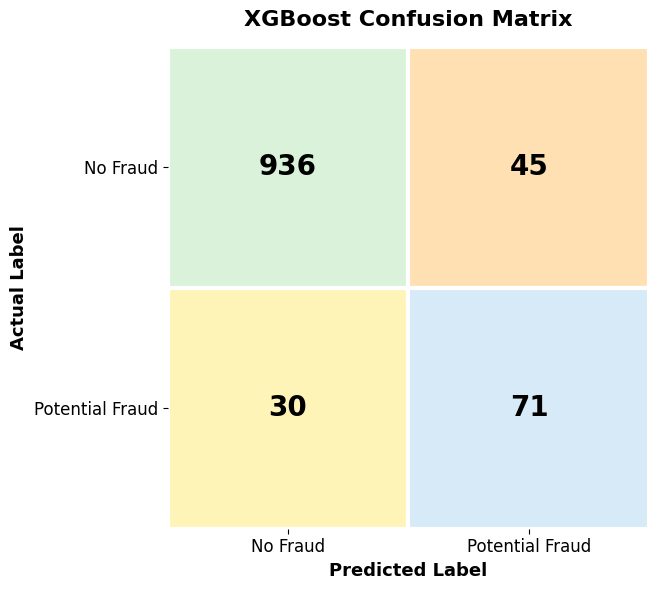

In [109]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(7, 6))

# Four light colors:
# TN = light green
# FP = light orange
# FN = light yellow
# TP = light blue

cell_colors = [
    ["#D9F2D9", "#FFE0B2"],   # TN, FP
    ["#FFF4B8", "#D6EAF8"]    # FN, TP
]

# Draw cells individually
for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j - 0.5, i - 0.5),
                1,
                1,
                facecolor=cell_colors[i][j],
                edgecolor="white",
                linewidth=3
            )
        )

        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=20,
            fontweight="bold"
        )

# Axis labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["No Fraud", "Potential Fraud"],
    fontsize=12
)

ax.set_yticklabels(
    ["No Fraud", "Potential Fraud"],
    fontsize=12
)

ax.set_xlabel(
    "Predicted Label",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Actual Label",
    fontsize=13,
    fontweight="bold"
)

ax.set_title(
    "XGBoost Confusion Matrix",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Keep square layout
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(1.5, -0.5)
ax.set_aspect("equal")

# Remove unnecessary borders
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

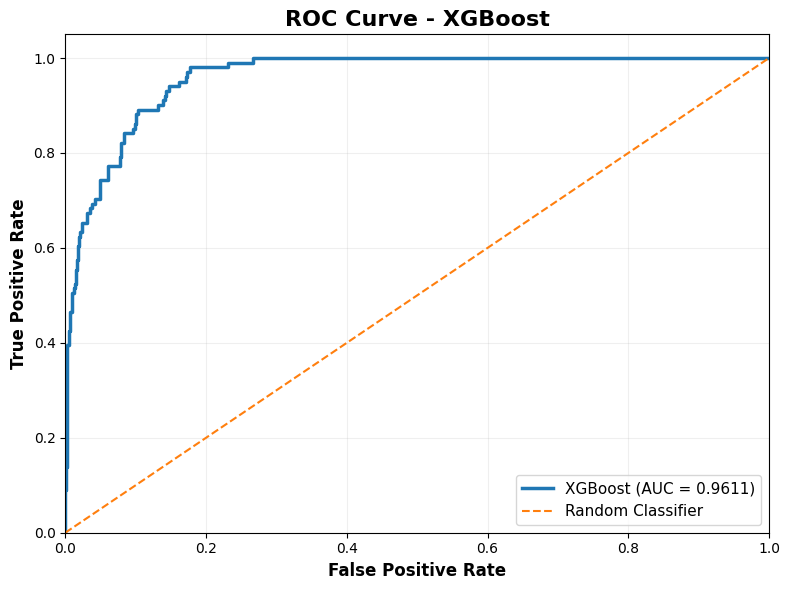

In [110]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y_val,
    y_val_proba
)

# Calculate ROC-AUC
roc_auc = roc_auc_score(
    y_val,
    y_val_proba
)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"XGBoost (AUC = {roc_auc:.4f})"
)

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "ROC Curve - XGBoost",
    fontsize=16,
    fontweight="bold"
)

plt.legend(
    loc="lower right",
    fontsize=11
)

plt.grid(
    alpha=0.2
)

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [111]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

threshold_results = []

for threshold in thresholds:

    predictions = (y_val_proba >= threshold).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    flagged = predictions.sum()

    threshold_results.append({
        "Threshold": threshold,
        "FlaggedProviders": flagged,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.to_string(index=False))

 Threshold  FlaggedProviders  Precision   Recall       F1
       0.1               227   0.400881 0.900990 0.554878
       0.2               186   0.473118 0.871287 0.613240
       0.3               153   0.509804 0.772277 0.614173
       0.4               133   0.563910 0.742574 0.641026
       0.5               116   0.612069 0.702970 0.654378
       0.6               101   0.673267 0.673267 0.673267
       0.7                88   0.738636 0.643564 0.687831
       0.8                72   0.777778 0.554455 0.647399
       0.9                57   0.842105 0.475248 0.607595


In [112]:
investigation_threshold = 0.60

validation_results = provider_val[
    ["Provider", "PotentialFraud"]
].copy()

validation_results["FraudProbability"] = y_val_proba

validation_results["PredictedFraud"] = (
    validation_results["FraudProbability"] >= investigation_threshold
).astype(int)

validation_results["RiskTier"] = pd.cut(
    validation_results["FraudProbability"],
    bins=[-np.inf, 0.30, 0.60, 0.80, np.inf],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk",
        "Very High Risk"
    ]
)

validation_results = validation_results.sort_values(
    "FraudProbability",
    ascending=False
).reset_index(drop=True)

print(validation_results.head(20).to_string(index=False))

print("\nRisk tier distribution:")
print(
    validation_results["RiskTier"]
    .value_counts()
    .sort_index()
)

Provider PotentialFraud  FraudProbability  PredictedFraud       RiskTier
PRV54772            Yes          0.998967               1 Very High Risk
PRV52985            Yes          0.998936               1 Very High Risk
PRV56416            Yes          0.998697               1 Very High Risk
PRV56560            Yes          0.998311               1 Very High Risk
PRV55435            Yes          0.998159               1 Very High Risk
PRV52340            Yes          0.998115               1 Very High Risk
PRV56647            Yes          0.997968               1 Very High Risk
PRV54742            Yes          0.997882               1 Very High Risk
PRV53797            Yes          0.997735               1 Very High Risk
PRV55916             No          0.997624               1 Very High Risk
PRV57172            Yes          0.997220               1 Very High Risk
PRV53421            Yes          0.997169               1 Very High Risk
PRV55215            Yes          0.996965          

In [115]:
# ============================================================
# PROVIDER-LEVEL MODEL COMPARISON
# Logistic Regression vs Random Forest vs XGBoost
# Threshold = 0.60
# ============================================================

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# 1. LOGISTIC REGRESSION
# ------------------------------------------------------------

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_proba = logistic_model.predict_proba(X_val)[:, 1]

# Investigation threshold
logistic_pred = (
    logistic_proba >= 0.60
).astype(int)


# ------------------------------------------------------------
# 2. RANDOM FOREST
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_proba = rf_model.predict_proba(X_val)[:, 1]

# Investigation threshold
rf_pred = (
    rf_proba >= 0.60
).astype(int)


# ------------------------------------------------------------
# 3. XGBOOST
# ------------------------------------------------------------
# Use your EXISTING XGBoost predictions from the notebook.
# y_val_proba = XGBoost probabilities
# y_val_pred  = existing XGBoost predictions

xgb_proba = y_val_proba

xgb_pred = (
    xgb_proba >= 0.60
).astype(int)


# ------------------------------------------------------------
# 4. EVALUATION FUNCTION
# ------------------------------------------------------------

def evaluate_model(name, y_true, y_pred, y_proba):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_proba
    )

    pr_auc = average_precision_score(
        y_true,
        y_proba
    )

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("\nConfusion Matrix:")
    print(cm)

    print("\nMetrics:")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"PR-AUC    : {pr_auc:.4f}")

    print(
        f"\nFlagged Providers: {y_pred.sum()}"
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Flagged Providers": int(y_pred.sum())
    }


# ------------------------------------------------------------
# 5. EVALUATE ALL THREE
# ------------------------------------------------------------

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_val,
        logistic_pred,
        logistic_proba
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_val,
        rf_pred,
        rf_proba
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_val,
        xgb_pred,
        xgb_proba
    )
)


# ------------------------------------------------------------
# 6. FINAL COMPARISON TABLE
# ------------------------------------------------------------

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    "PR-AUC",
    ascending=False
).reset_index(drop=True)

print("\n\n")
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("Threshold = 0.60")
print("=" * 80)

print(
    comparison_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


Logistic Regression

Confusion Matrix:
[[876 105]
 [ 13  88]]

Metrics:
Accuracy  : 0.8909
Precision : 0.4560
Recall    : 0.8713
F1 Score  : 0.5986
ROC-AUC   : 0.9654
PR-AUC    : 0.7788

Flagged Providers: 193

Random Forest

Confusion Matrix:
[[950  31]
 [ 32  69]]

Metrics:
Accuracy  : 0.9418
Precision : 0.6900
Recall    : 0.6832
F1 Score  : 0.6866
ROC-AUC   : 0.9594
PR-AUC    : 0.7040

Flagged Providers: 100

XGBoost

Confusion Matrix:
[[948  33]
 [ 33  68]]

Metrics:
Accuracy  : 0.9390
Precision : 0.6733
Recall    : 0.6733
F1 Score  : 0.6733
ROC-AUC   : 0.9611
PR-AUC    : 0.7484

Flagged Providers: 101



FINAL MODEL COMPARISON
Threshold = 0.60
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC  Flagged Providers
Logistic Regression    0.8909     0.4560  0.8713 0.5986   0.9654  0.7788                193
            XGBoost    0.9390     0.6733  0.6733 0.6733   0.9611  0.7484                101
      Random Forest    0.9418     0.6900  0.6832 0.6866   0.9594  

In [113]:
import pandas as pd

dataframes = [
    (name, obj)
    for name, obj in list(globals().items())
    if isinstance(obj, pd.DataFrame)
]

for name, obj in dataframes:
    print(f"{name:30} Shape: {obj.shape}")

Train                          Shape: (5410, 2)
Train_Beneficiarydata          Shape: (138556, 25)
Train_Inpatientdata            Shape: (40474, 30)
Train_Outpatientdata           Shape: (517737, 27)
Test                           Shape: (1353, 1)
Test_Beneficiarydata           Shape: (63968, 25)
Test_Inpatientdata             Shape: (9551, 30)
Test_Outpatientdata            Shape: (125841, 27)
df                             Shape: (125841, 27)
missing_table                  Shape: (27, 2)
inpatient                      Shape: (40474, 31)
outpatient                     Shape: (517737, 28)
unified_claims                 Shape: (558211, 68)
date_check                     Shape: (2, 3)
provider_features              Shape: (5410, 52)
claim_type_counts              Shape: (5410, 3)
peer_stats                     Shape: (9, 9)
peer_means                     Shape: (9, 4)
peer_stats_z                   Shape: (9, 6)
inpatient_features             Shape: (2092, 7)
outpatient_features         

In [116]:
# ============================================================
# STEP 1: PREPARE CLAIM-LEVEL ANOMALY DATA
# ============================================================

claims_anomaly = unified_claims.copy()

print("Claim anomaly dataframe shape:")
print(claims_anomaly.shape)

print("\nColumns:")
for i, col in enumerate(claims_anomaly.columns, 1):
    print(f"{i:2}. {col}")

Claim anomaly dataframe shape:
(558211, 68)

Columns:
 1. BeneID
 2. ClaimID
 3. ClaimStartDt
 4. ClaimEndDt
 5. Provider
 6. InscClaimAmtReimbursed
 7. AttendingPhysician
 8. OperatingPhysician
 9. OtherPhysician
10. AdmissionDt
11. ClmAdmitDiagnosisCode
12. DeductibleAmtPaid
13. DischargeDt
14. DiagnosisGroupCode
15. ClmDiagnosisCode_1
16. ClmDiagnosisCode_2
17. ClmDiagnosisCode_3
18. ClmDiagnosisCode_4
19. ClmDiagnosisCode_5
20. ClmDiagnosisCode_6
21. ClmDiagnosisCode_7
22. ClmDiagnosisCode_8
23. ClmDiagnosisCode_9
24. ClmDiagnosisCode_10
25. ClmProcedureCode_1
26. ClmProcedureCode_2
27. ClmProcedureCode_3
28. ClmProcedureCode_4
29. ClmProcedureCode_5
30. ClmProcedureCode_6
31. ClaimType
32. DOB
33. DOD
34. Gender
35. Race
36. RenalDiseaseIndicator
37. State
38. County
39. NoOfMonths_PartACov
40. NoOfMonths_PartBCov
41. ChronicCond_Alzheimer
42. ChronicCond_Heartfailure
43. ChronicCond_KidneyDisease
44. ChronicCond_Cancer
45. ChronicCond_ObstrPulmonary
46. ChronicCond_Depression
47.

In [117]:
# ============================================================
# CHECK EXISTING CLAIM-LEVEL FEATURES
# ============================================================

claim_features_expected = [
    "ClaimID",
    "Provider",
    "ClaimType",
    "ClaimDurationDays",
    "ClaimReimbursement",
    "ClaimDeductible",
    "TotalClaimCost",
    "ReimbursementPerClaimDay",
    "BeneficiaryAge",
    "ChronicConditionCount",
    "DiagnosisCodeCount",
    "ProcedureCodeCount",
    "PhysicianCount"
]

print("Existing claim features:")
for col in claim_features_expected:
    if col in claims_anomaly.columns:
        print(f"✓ {col}")
    else:
        print(f"✗ {col} NOT FOUND")

Existing claim features:
✓ ClaimID
✓ Provider
✓ ClaimType
✓ ClaimDurationDays
✓ ClaimReimbursement
✓ ClaimDeductible
✓ TotalClaimCost
✓ ReimbursementPerClaimDay
✓ BeneficiaryAge
✓ ChronicConditionCount
✓ DiagnosisCodeCount
✓ ProcedureCodeCount
✓ PhysicianCount


In [118]:
# ============================================================
# STEP 2: CREATE PROVIDER BASELINE TABLE
# ============================================================

provider_baselines = provider_features[
    [
        "Provider",
        "AverageClaimReimbursement",
        "MedianClaimReimbursement",
        "AverageClaimDuration",
        "AverageReimbursementPerClaimDay",
        "AverageDiagnosisCount",
        "AverageProcedureCount",
        "AveragePhysicianCount",
        "AverageBeneficiaryAge",
        "AverageChronicConditions"
    ]
].copy()

print("Provider baseline shape:")
print(provider_baselines.shape)

print("\nMissing values:")
print(provider_baselines.isna().sum())

print("\nDuplicate providers:")
print(provider_baselines["Provider"].duplicated().sum())

Provider baseline shape:
(5410, 10)

Missing values:
Provider                           0
AverageClaimReimbursement          0
MedianClaimReimbursement           0
AverageClaimDuration               0
AverageReimbursementPerClaimDay    0
AverageDiagnosisCount              0
AverageProcedureCount              0
AveragePhysicianCount              0
AverageBeneficiaryAge              0
AverageChronicConditions           0
dtype: int64

Duplicate providers:
0


In [119]:
# ============================================================
# STEP 3: MERGE PROVIDER BASELINES INTO CLAIMS
# ============================================================

claims_anomaly = unified_claims.copy()

claims_anomaly = claims_anomaly.merge(
    provider_baselines,
    on="Provider",
    how="left",
    suffixes=("", "_Provider")
)

print("After merge:")
print("Shape:", claims_anomaly.shape)

print("\nOriginal claims:", len(unified_claims))
print("After merge:", len(claims_anomaly))

assert len(claims_anomaly) == len(unified_claims)

print("\n✓ Row count preserved")

After merge:
Shape: (558211, 77)

Original claims: 558211
After merge: 558211

✓ Row count preserved


In [120]:
# ============================================================
# STEP 4: CLAIM vs PROVIDER RELATIVE FEATURES
# ============================================================

# 1. Reimbursement relative to provider average
claims_anomaly["ClaimReimbursement_vs_ProviderMean"] = (
    claims_anomaly["ClaimReimbursement"]
    / claims_anomaly["AverageClaimReimbursement"].replace(0, np.nan)
)

# 2. Reimbursement relative to provider median
claims_anomaly["ClaimReimbursement_vs_ProviderMedian"] = (
    claims_anomaly["ClaimReimbursement"]
    / claims_anomaly["MedianClaimReimbursement"].replace(0, np.nan)
)

# 3. Claim duration relative to provider average
claims_anomaly["ClaimDuration_vs_ProviderMean"] = (
    claims_anomaly["ClaimDurationDays"]
    / claims_anomaly["AverageClaimDuration"].replace(0, np.nan)
)

# 4. Reimbursement per claim day relative to provider average
claims_anomaly["ReimbursementPerClaimDay_vs_ProviderMean"] = (
    claims_anomaly["ReimbursementPerClaimDay"]
    / claims_anomaly["AverageReimbursementPerClaimDay"].replace(0, np.nan)
)

# 5. Diagnosis count relative to provider average
claims_anomaly["DiagnosisCount_vs_ProviderMean"] = (
    claims_anomaly["DiagnosisCodeCount"]
    / claims_anomaly["AverageDiagnosisCount"].replace(0, np.nan)
)

# 6. Procedure count relative to provider average
claims_anomaly["ProcedureCount_vs_ProviderMean"] = (
    claims_anomaly["ProcedureCodeCount"]
    / claims_anomaly["AverageProcedureCount"].replace(0, np.nan)
)

# 7. Physician count relative to provider average
claims_anomaly["PhysicianCount_vs_ProviderMean"] = (
    claims_anomaly["PhysicianCount"]
    / claims_anomaly["AveragePhysicianCount"].replace(0, np.nan)
)

# 8. Beneficiary age difference from provider average
claims_anomaly["BeneficiaryAge_vs_ProviderMean"] = (
    claims_anomaly["BeneficiaryAge"]
    - claims_anomaly["AverageBeneficiaryAge"]
)

# 9. Chronic-condition difference from provider average
claims_anomaly["ChronicConditions_vs_ProviderMean"] = (
    claims_anomaly["ChronicConditionCount"]
    - claims_anomaly["AverageChronicConditions"]
)

print("Claim-relative features created.")

relative_features = [
    "ClaimReimbursement_vs_ProviderMean",
    "ClaimReimbursement_vs_ProviderMedian",
    "ClaimDuration_vs_ProviderMean",
    "ReimbursementPerClaimDay_vs_ProviderMean",
    "DiagnosisCount_vs_ProviderMean",
    "ProcedureCount_vs_ProviderMean",
    "PhysicianCount_vs_ProviderMean",
    "BeneficiaryAge_vs_ProviderMean",
    "ChronicConditions_vs_ProviderMean"
]

print("\nNumber of relative features:", len(relative_features))

print("\nMissing values:")
print(claims_anomaly[relative_features].isna().sum())

print("\nInfinite values:")
print(
    np.isinf(
        claims_anomaly[relative_features]
        .select_dtypes(include=np.number)
    ).sum()
)

Claim-relative features created.

Number of relative features: 9

Missing values:
ClaimReimbursement_vs_ProviderMean              15
ClaimReimbursement_vs_ProviderMedian            18
ClaimDuration_vs_ProviderMean                 3904
ReimbursementPerClaimDay_vs_ProviderMean        15
DiagnosisCount_vs_ProviderMean                   5
ProcedureCount_vs_ProviderMean              246276
PhysicianCount_vs_ProviderMean                   0
BeneficiaryAge_vs_ProviderMean                   0
ChronicConditions_vs_ProviderMean                0
dtype: int64

Infinite values:
ClaimReimbursement_vs_ProviderMean          0
ClaimReimbursement_vs_ProviderMedian        0
ClaimDuration_vs_ProviderMean               0
ReimbursementPerClaimDay_vs_ProviderMean    0
DiagnosisCount_vs_ProviderMean              0
ProcedureCount_vs_ProviderMean              0
PhysicianCount_vs_ProviderMean              0
BeneficiaryAge_vs_ProviderMean              0
ChronicConditions_vs_ProviderMean           0
dtype: int64


In [121]:
# ============================================================
# STEP 5: ZERO-BASELINE INDICATORS
# ============================================================

claims_anomaly["ProviderProcedureBaselineZero"] = (
    claims_anomaly["AverageProcedureCount"] == 0
).astype(int)

claims_anomaly["ProviderDiagnosisBaselineZero"] = (
    claims_anomaly["AverageDiagnosisCount"] == 0
).astype(int)

claims_anomaly["ProviderDurationBaselineZero"] = (
    claims_anomaly["AverageClaimDuration"] == 0
).astype(int)

claims_anomaly["ProviderReimbursementBaselineZero"] = (
    claims_anomaly["AverageClaimReimbursement"] == 0
).astype(int)

claims_anomaly["ProviderReimbursementDayBaselineZero"] = (
    claims_anomaly["AverageReimbursementPerClaimDay"] == 0
).astype(int)

claims_anomaly["ProviderMedianReimbursementBaselineZero"] = (
    claims_anomaly["MedianClaimReimbursement"] == 0
).astype(int)

print("Zero-baseline indicators created.\n")

zero_baseline_features = [
    "ProviderProcedureBaselineZero",
    "ProviderDiagnosisBaselineZero",
    "ProviderDurationBaselineZero",
    "ProviderReimbursementBaselineZero",
    "ProviderReimbursementDayBaselineZero",
    "ProviderMedianReimbursementBaselineZero"
]

print(
    claims_anomaly[zero_baseline_features]
    .sum()
)

Zero-baseline indicators created.

ProviderProcedureBaselineZero              246276
ProviderDiagnosisBaselineZero                   5
ProviderDurationBaselineZero                 3904
ProviderReimbursementBaselineZero              15
ProviderReimbursementDayBaselineZero           15
ProviderMedianReimbursementBaselineZero        18
dtype: int64


In [122]:
# ============================================================
# STEP 6: HANDLE UNDEFINED RELATIVE FEATURES
# ============================================================

relative_features = [
    "ClaimReimbursement_vs_ProviderMean",
    "ClaimReimbursement_vs_ProviderMedian",
    "ClaimDuration_vs_ProviderMean",
    "ReimbursementPerClaimDay_vs_ProviderMean",
    "DiagnosisCount_vs_ProviderMean",
    "ProcedureCount_vs_ProviderMean",
    "PhysicianCount_vs_ProviderMean",
    "BeneficiaryAge_vs_ProviderMean",
    "ChronicConditions_vs_ProviderMean"
]

# Replace undefined ratios with neutral value
claims_anomaly[relative_features] = (
    claims_anomaly[relative_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("Missing values after handling:")
print(
    claims_anomaly[relative_features]
    .isna()
    .sum()
)

print("\nInfinite values after handling:")

print(
    np.isinf(
        claims_anomaly[relative_features]
        .to_numpy()
    ).sum()
)

Missing values after handling:
ClaimReimbursement_vs_ProviderMean          0
ClaimReimbursement_vs_ProviderMedian        0
ClaimDuration_vs_ProviderMean               0
ReimbursementPerClaimDay_vs_ProviderMean    0
DiagnosisCount_vs_ProviderMean              0
ProcedureCount_vs_ProviderMean              0
PhysicianCount_vs_ProviderMean              0
BeneficiaryAge_vs_ProviderMean              0
ChronicConditions_vs_ProviderMean           0
dtype: int64

Infinite values after handling:
0


In [123]:
# ============================================================
# STEP 7: CLAIM FEATURE INTEGRITY CHECK
# ============================================================

print("=" * 70)
print("CLAIM-LEVEL FEATURE INTEGRITY")
print("=" * 70)

print("\nRows:", len(claims_anomaly))
print("Unique ClaimIDs:", claims_anomaly["ClaimID"].nunique())
print(
    "Duplicate ClaimIDs:",
    claims_anomaly["ClaimID"].duplicated().sum()
)

print("\nMissing values:")
print(
    claims_anomaly[relative_features]
    .isna()
    .sum()
)

print("\nInfinite values:")
print(
    np.isinf(
        claims_anomaly[relative_features].to_numpy()
    ).sum()
)

CLAIM-LEVEL FEATURE INTEGRITY

Rows: 558211
Unique ClaimIDs: 558211
Duplicate ClaimIDs: 0

Missing values:
ClaimReimbursement_vs_ProviderMean          0
ClaimReimbursement_vs_ProviderMedian        0
ClaimDuration_vs_ProviderMean               0
ReimbursementPerClaimDay_vs_ProviderMean    0
DiagnosisCount_vs_ProviderMean              0
ProcedureCount_vs_ProviderMean              0
PhysicianCount_vs_ProviderMean              0
BeneficiaryAge_vs_ProviderMean              0
ChronicConditions_vs_ProviderMean           0
dtype: int64

Infinite values:
0


In [124]:
# ============================================================
# STEP 8: RELATIVE FEATURE DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 70)
print("RELATIVE FEATURE DISTRIBUTIONS")
print("=" * 70)

print(
    claims_anomaly[relative_features]
    .describe()
    .T
)


RELATIVE FEATURE DISTRIBUTIONS
                                             count          mean        std  \
ClaimReimbursement_vs_ProviderMean        558211.0  9.999731e-01   2.658711   
ClaimReimbursement_vs_ProviderMedian      558211.0  7.277248e+00  29.801850   
ClaimDuration_vs_ProviderMean             558211.0  9.930062e-01   3.097815   
ReimbursementPerClaimDay_vs_ProviderMean  558211.0  9.999731e-01   2.218180   
DiagnosisCount_vs_ProviderMean            558211.0  9.999910e-01   0.765373   
ProcedureCount_vs_ProviderMean            558211.0  5.588120e-01  15.867392   
PhysicianCount_vs_ProviderMean            558211.0  1.000000e+00   0.404360   
BeneficiaryAge_vs_ProviderMean            558211.0  1.949563e-16  12.872881   
ChronicConditions_vs_ProviderMean         558211.0  2.230108e-17   2.305070   

                                                min       25%       50%  \
ClaimReimbursement_vs_ProviderMean         0.000000  0.068852  0.214882   
ClaimReimbursement_vs_Provi

In [125]:
# ============================================================
# STEP 9: ROBUST CLAIM ANOMALY FEATURES
# ============================================================

# ------------------------------------------------------------
# 1. Log-transform highly skewed positive ratios
# ------------------------------------------------------------

claims_anomaly["Log_ClaimReimbursement_vs_ProviderMean"] = np.log1p(
    claims_anomaly["ClaimReimbursement_vs_ProviderMean"]
)

claims_anomaly["Log_ClaimReimbursement_vs_ProviderMedian"] = np.log1p(
    claims_anomaly["ClaimReimbursement_vs_ProviderMedian"]
)

claims_anomaly["Log_ReimbursementPerClaimDay_vs_ProviderMean"] = np.log1p(
    claims_anomaly["ReimbursementPerClaimDay_vs_ProviderMean"]
)

claims_anomaly["Log_DiagnosisCount_vs_ProviderMean"] = np.log1p(
    claims_anomaly["DiagnosisCount_vs_ProviderMean"]
)

claims_anomaly["Log_PhysicianCount_vs_ProviderMean"] = np.log1p(
    claims_anomaly["PhysicianCount_vs_ProviderMean"]
)

# ------------------------------------------------------------
# 2. Duration:
# Keep raw duration + create a log version of the ratio
# ------------------------------------------------------------

claims_anomaly["Log_ClaimDuration_vs_ProviderMean"] = np.log1p(
    claims_anomaly["ClaimDuration_vs_ProviderMean"]
)

# ------------------------------------------------------------
# 3. Procedure behavior
#
# The ratio is unreliable because many providers have
# AverageProcedureCount = 0.
#
# Instead, retain:
#   - raw ProcedureCodeCount
#   - zero-baseline indicator
#
# ------------------------------------------------------------

claims_anomaly["ProcedureCount_WhenProviderBaselineZero"] = (
    (
        claims_anomaly["ProviderProcedureBaselineZero"] == 1
    ) &
    (
        claims_anomaly["ProcedureCodeCount"] > 0
    )
).astype(int)

# ------------------------------------------------------------
# 4. Absolute beneficiary / chronic-condition deviations
# ------------------------------------------------------------

claims_anomaly["Abs_BeneficiaryAge_vs_ProviderMean"] = (
    claims_anomaly["BeneficiaryAge_vs_ProviderMean"].abs()
)

claims_anomaly["Abs_ChronicConditions_vs_ProviderMean"] = (
    claims_anomaly["ChronicConditions_vs_ProviderMean"].abs()
)

print("Robust anomaly features created.")

Robust anomaly features created.


In [126]:
# ============================================================
# STEP 10: VALIDATE ROBUST ANOMALY FEATURES
# ============================================================

robust_features = [
    "Log_ClaimReimbursement_vs_ProviderMean",
    "Log_ClaimReimbursement_vs_ProviderMedian",
    "Log_ClaimDuration_vs_ProviderMean",
    "Log_ReimbursementPerClaimDay_vs_ProviderMean",
    "Log_DiagnosisCount_vs_ProviderMean",
    "Log_PhysicianCount_vs_ProviderMean",
    "Abs_BeneficiaryAge_vs_ProviderMean",
    "Abs_ChronicConditions_vs_ProviderMean",
    "ProcedureCount_WhenProviderBaselineZero"
]

print("=" * 70)
print("ROBUST ANOMALY FEATURE VALIDATION")
print("=" * 70)

print("\nMissing values:")
print(
    claims_anomaly[robust_features]
    .isna()
    .sum()
)

print("\nInfinite values:")
print(
    np.isinf(
        claims_anomaly[robust_features].to_numpy()
    ).sum()
)

print("\nDistributions:")
print(
    claims_anomaly[robust_features]
    .describe()
    .T
)

ROBUST ANOMALY FEATURE VALIDATION

Missing values:
Log_ClaimReimbursement_vs_ProviderMean          0
Log_ClaimReimbursement_vs_ProviderMedian        0
Log_ClaimDuration_vs_ProviderMean               0
Log_ReimbursementPerClaimDay_vs_ProviderMean    0
Log_DiagnosisCount_vs_ProviderMean              0
Log_PhysicianCount_vs_ProviderMean              0
Abs_BeneficiaryAge_vs_ProviderMean              0
Abs_ChronicConditions_vs_ProviderMean           0
ProcedureCount_WhenProviderBaselineZero         0
dtype: int64

Infinite values:
0

Distributions:
                                                 count      mean       std  \
Log_ClaimReimbursement_vs_ProviderMean        558211.0  0.433369  0.578441   
Log_ClaimReimbursement_vs_ProviderMedian      558211.0  1.083642  1.078972   
Log_ClaimDuration_vs_ProviderMean             558211.0  0.277817  0.686869   
Log_ReimbursementPerClaimDay_vs_ProviderMean  558211.0  0.466716  0.555007   
Log_DiagnosisCount_vs_ProviderMean            558211.0  0.63

In [127]:
# ============================================================
# STEP 11: FINAL CLAIM-LEVEL ISOLATION FOREST FEATURES
# ============================================================

claim_model_features = [
    # --------------------------------------------------------
    # Original claim-level behavior
    # --------------------------------------------------------
    "ClaimDurationDays",
    "ClaimReimbursement",
    "ClaimDeductible",
    "TotalClaimCost",
    "ReimbursementPerClaimDay",

    "BeneficiaryAge",
    "ChronicConditionCount",

    "DiagnosisCodeCount",
    "ProcedureCodeCount",
    "PhysicianCount",

    # --------------------------------------------------------
    # Provider-relative financial behavior
    # --------------------------------------------------------
    "Log_ClaimReimbursement_vs_ProviderMean",
    "Log_ClaimReimbursement_vs_ProviderMedian",
    "Log_ReimbursementPerClaimDay_vs_ProviderMean",

    # --------------------------------------------------------
    # Provider-relative utilization behavior
    # --------------------------------------------------------
    "Log_ClaimDuration_vs_ProviderMean",
    "Log_DiagnosisCount_vs_ProviderMean",
    "Log_PhysicianCount_vs_ProviderMean",

    # --------------------------------------------------------
    # Provider-relative beneficiary behavior
    # --------------------------------------------------------
    "Abs_BeneficiaryAge_vs_ProviderMean",
    "Abs_ChronicConditions_vs_ProviderMean"
]

print("Number of claim model features:", len(claim_model_features))

print("\nClaim model features:")
for i, feature in enumerate(claim_model_features, 1):
    print(f"{i:2}. {feature}")

Number of claim model features: 18

Claim model features:
 1. ClaimDurationDays
 2. ClaimReimbursement
 3. ClaimDeductible
 4. TotalClaimCost
 5. ReimbursementPerClaimDay
 6. BeneficiaryAge
 7. ChronicConditionCount
 8. DiagnosisCodeCount
 9. ProcedureCodeCount
10. PhysicianCount
11. Log_ClaimReimbursement_vs_ProviderMean
12. Log_ClaimReimbursement_vs_ProviderMedian
13. Log_ReimbursementPerClaimDay_vs_ProviderMean
14. Log_ClaimDuration_vs_ProviderMean
15. Log_DiagnosisCount_vs_ProviderMean
16. Log_PhysicianCount_vs_ProviderMean
17. Abs_BeneficiaryAge_vs_ProviderMean
18. Abs_ChronicConditions_vs_ProviderMean


In [128]:
# ============================================================
# STEP 13: CREATE FINAL CLAIM MODEL MATRIX
# ============================================================

X_claim = claims_anomaly[claim_model_features].copy()

print("X_claim shape:", X_claim.shape)

print("\nMissing values:")
print(X_claim.isna().sum().sum())

print("\nInfinite values:")
print(np.isinf(X_claim.to_numpy()).sum())

X_claim shape: (558211, 18)

Missing values:
0

Infinite values:
0


In [130]:
# ============================================================
# STEP 14: TRAIN ISOLATION FOREST
# ============================================================

from sklearn.ensemble import IsolationForest

claim_isolation_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

claim_isolation_forest.fit(X_claim)

print("✓ Isolation Forest training completed.")

✓ Isolation Forest training completed.


In [139]:
print(claims_anomaly.columns.tolist())

['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'ClaimType', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumato

In [131]:
# ============================================================
# STEP 15: CLAIM ANOMALY SCORES
# ============================================================

# sklearn:
# -1 = anomaly
# +1 = normal

claims_anomaly["IsolationPrediction"] = (
    claim_isolation_forest.predict(X_claim)
)

# decision_function:
# Higher = more normal
# Lower = more anomalous
claims_anomaly["IsolationScore"] = (
    claim_isolation_forest.decision_function(X_claim)
)

# Convert so HIGHER = MORE suspicious
claims_anomaly["ClaimAnomalyScore"] = (
    -claims_anomaly["IsolationScore"]
)

print("Prediction distribution:")
print(
    claims_anomaly["IsolationPrediction"]
    .value_counts()
)

print("\nAnomaly score statistics:")
print(
    claims_anomaly["ClaimAnomalyScore"]
    .describe()
)

Prediction distribution:
IsolationPrediction
 1    470739
-1     87472
Name: count, dtype: int64

Anomaly score statistics:
count    558211.000000
mean         -0.070328
std           0.071631
min          -0.147561
25%          -0.122530
50%          -0.096393
75%          -0.043005
max           0.260119
Name: ClaimAnomalyScore, dtype: float64


In [140]:
# Isolation Forest anomaly summary

print("Isolation Forest Prediction Distribution")
print("=" * 50)

print(
    claims_anomaly["IsolationPrediction"]
    .value_counts()
    .rename({
        1: "Normal Claims",
        -1: "Anomalous Claims"
    })
)

print("\nAnomaly Score Statistics")
print("=" * 50)

print(
    claims_anomaly["ClaimAnomalyScore"].describe()
)

Isolation Forest Prediction Distribution
IsolationPrediction
Normal Claims       470739
Anomalous Claims     87472
Name: count, dtype: int64

Anomaly Score Statistics
count    558211.000000
mean         -0.070328
std           0.071631
min          -0.147561
25%          -0.122530
50%          -0.096393
75%          -0.043005
max           0.260119
Name: ClaimAnomalyScore, dtype: float64


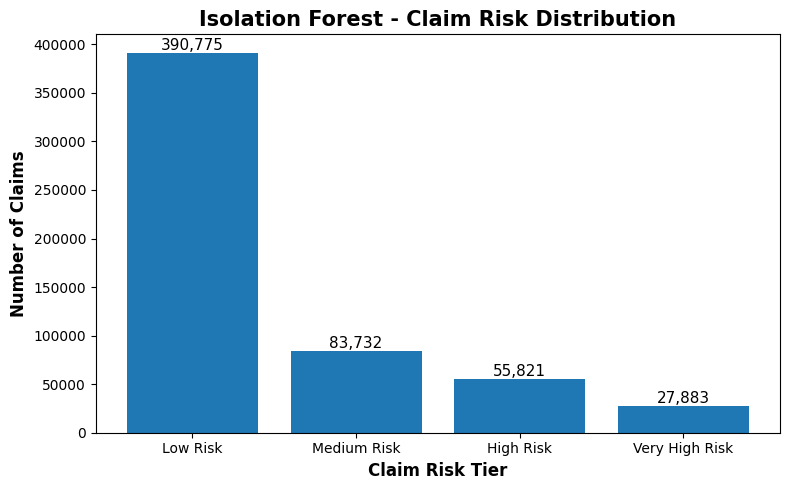

In [141]:
import matplotlib.pyplot as plt

risk_counts = (
    claims_anomaly["ClaimRiskTier"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    risk_counts.index.astype(str),
    risk_counts.values
)

plt.xlabel(
    "Claim Risk Tier",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Claims",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "Isolation Forest - Claim Risk Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=0)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [132]:
# ============================================================
# STEP 16: TOP ANOMALOUS CLAIMS
# ============================================================

top_anomalous_claims = (
    claims_anomaly[
        [
            "ClaimID",
            "Provider",
            "ClaimType",
            "ClaimReimbursement",
            "ClaimDurationDays",
            "DiagnosisCodeCount",
            "ProcedureCodeCount",
            "PhysicianCount",
            "ClaimAnomalyScore"
        ]
    ]
    .sort_values(
        "ClaimAnomalyScore",
        ascending=False
    )
    .head(20)
)

print(
    top_anomalous_claims
    .to_string(index=False)
)

 ClaimID Provider ClaimType  ClaimReimbursement  ClaimDurationDays  DiagnosisCodeCount  ProcedureCodeCount  PhysicianCount  ClaimAnomalyScore
CLM65501 PRV53762 Inpatient              112000                 14                  10                   1               3           0.260119
CLM54728 PRV52401 Inpatient               36000                  5                   9                   2               3           0.255230
CLM71575 PRV57543 Inpatient               33000                 14                   9                   2               3           0.251361
CLM41955 PRV52842 Inpatient               68000                 10                   9                   2               3           0.250875
CLM52406 PRV51578 Inpatient               46000                  5                  10                   1               2           0.250413
CLM70572 PRV54111 Inpatient               57000                  4                   9                   2               3           0.249687
CLM321

In [133]:
# ============================================================
# STEP 17: NORMALIZED CLAIM ANOMALY SCORE
# ============================================================

claims_anomaly["ClaimAnomalyPercentile"] = (
    claims_anomaly["ClaimAnomalyScore"]
    .rank(pct=True) * 100
)

claims_anomaly["ClaimAnomalyScore100"] = (
    claims_anomaly["ClaimAnomalyPercentile"]
    .round(2)
)

print(
    claims_anomaly[
        [
            "ClaimID",
            "ClaimAnomalyScore",
            "ClaimAnomalyScore100"
        ]
    ]
    .sort_values(
        "ClaimAnomalyScore100",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

 ClaimID  ClaimAnomalyScore  ClaimAnomalyScore100
CLM43233           0.245916                 100.0
CLM36402           0.243787                 100.0
CLM52406           0.250413                 100.0
CLM31995           0.242485                 100.0
CLM33508           0.241112                 100.0
CLM70572           0.249687                 100.0
CLM75805           0.245581                 100.0
CLM42656           0.241535                 100.0
CLM60598           0.247327                 100.0
CLM76727           0.243345                 100.0
CLM70578           0.240445                 100.0
CLM32949           0.241788                 100.0
CLM45236           0.244463                 100.0
CLM65894           0.242864                 100.0
CLM71575           0.251361                 100.0
CLM50559           0.240356                 100.0
CLM41955           0.250875                 100.0
CLM65501           0.260119                 100.0
CLM42975           0.243194                 100.0


In [134]:
# ============================================================
# STEP 19: CLAIM ANOMALY REASON SIGNALS
# ============================================================

# Create a copy for reason analysis
claim_reasons = claims_anomaly.copy()

# ------------------------------------------------------------
# Financial anomaly
# ------------------------------------------------------------

claim_reasons["Reason_Reimbursement"] = (
    claim_reasons["Log_ClaimReimbursement_vs_ProviderMean"]
)

claim_reasons["Reason_ReimbursementMedian"] = (
    claim_reasons["Log_ClaimReimbursement_vs_ProviderMedian"]
)

claim_reasons["Reason_ReimbursementPerDay"] = (
    claim_reasons["Log_ReimbursementPerClaimDay_vs_ProviderMean"]
)

# ------------------------------------------------------------
# Utilization anomaly
# ------------------------------------------------------------

claim_reasons["Reason_Diagnosis"] = (
    claim_reasons["Log_DiagnosisCount_vs_ProviderMean"]
)

claim_reasons["Reason_Physician"] = (
    claim_reasons["Log_PhysicianCount_vs_ProviderMean"]
)

claim_reasons["Reason_Duration"] = (
    claim_reasons["Log_ClaimDuration_vs_ProviderMean"]
)

# ------------------------------------------------------------
# Beneficiary / clinical-pattern anomaly
# ------------------------------------------------------------

claim_reasons["Reason_Age"] = (
    claim_reasons["Abs_BeneficiaryAge_vs_ProviderMean"]
)

claim_reasons["Reason_ChronicConditions"] = (
    claim_reasons["Abs_ChronicConditions_vs_ProviderMean"]
)

print("Claim anomaly reason signals created.")

Claim anomaly reason signals created.


In [135]:
# ============================================================
# STEP 18: CLAIM RISK TIERS
# ============================================================

claims_anomaly["ClaimRiskTier"] = pd.cut(
    claims_anomaly["ClaimAnomalyScore100"],
    bins=[-np.inf, 70, 85, 95, np.inf],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk",
        "Very High Risk"
    ]
)

print("Claim risk distribution:")
print(
    claims_anomaly["ClaimRiskTier"]
    .value_counts()
    .sort_index()
)

Claim risk distribution:
ClaimRiskTier
Low Risk          390775
Medium Risk        83732
High Risk          55821
Very High Risk     27883
Name: count, dtype: int64


In [136]:
# ============================================================
# STEP 20: NORMALIZE REASON SIGNALS
# ============================================================

reason_features = [
    "Reason_Reimbursement",
    "Reason_ReimbursementMedian",
    "Reason_ReimbursementPerDay",
    "Reason_Diagnosis",
    "Reason_Physician",
    "Reason_Duration",
    "Reason_Age",
    "Reason_ChronicConditions"
]

for feature in reason_features:

    min_value = claim_reasons[feature].min()
    max_value = claim_reasons[feature].max()

    if max_value > min_value:
        claim_reasons[feature + "_Normalized"] = (
            (claim_reasons[feature] - min_value)
            / (max_value - min_value)
        )
    else:
        claim_reasons[feature + "_Normalized"] = 0

normalized_reason_features = [
    feature + "_Normalized"
    for feature in reason_features
]

print("Normalized reason features created.")

print(
    claim_reasons[normalized_reason_features]
    .describe()
    .T
)

Normalized reason features created.
                                          count      mean       std  min  \
Reason_Reimbursement_Normalized        558211.0  0.081111  0.108264  0.0   
Reason_ReimbursementMedian_Normalized  558211.0  0.145027  0.144402  0.0   
Reason_ReimbursementPerDay_Normalized  558211.0  0.098797  0.117486  0.0   
Reason_Diagnosis_Normalized            558211.0  0.349789  0.188923  0.0   
Reason_Physician_Normalized            558211.0  0.536408  0.156008  0.0   
Reason_Duration_Normalized             558211.0  0.061786  0.152759  0.0   
Reason_Age_Normalized                  558211.0  0.180993  0.160598  0.0   
Reason_ChronicConditions_Normalized    558211.0  0.258906  0.174533  0.0   

                                            25%       50%       75%  max  
Reason_Reimbursement_Normalized        0.012462  0.036431  0.102774  1.0  
Reason_ReimbursementMedian_Normalized  0.049214  0.092766  0.196244  1.0  
Reason_ReimbursementPerDay_Normalized  0.021839  0.053

In [137]:
# ============================================================
# STEP 21: GENERATE HUMAN-READABLE ANOMALY REASONS
# ============================================================

reason_labels = {
    "Reason_Reimbursement_Normalized":
        "Unusually high reimbursement compared with provider",

    "Reason_ReimbursementMedian_Normalized":
        "Reimbursement is far above provider's typical claim",

    "Reason_ReimbursementPerDay_Normalized":
        "Unusually high reimbursement per claim day",

    "Reason_Diagnosis_Normalized":
        "Unusually high diagnosis-code count",

    "Reason_Physician_Normalized":
        "Unusually high physician count",

    "Reason_Duration_Normalized":
        "Unusually long claim duration",

    "Reason_Age_Normalized":
        "Beneficiary age differs substantially from provider pattern",

    "Reason_ChronicConditions_Normalized":
        "Chronic-condition pattern differs substantially from provider pattern"
}

def get_top_reasons(row, top_n=3):

    scores = {
        label: row[column]
        for column, label in reason_labels.items()
    }

    sorted_reasons = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return sorted_reasons[:top_n]


claim_reasons["TopAnomalyReasons"] = (
    claim_reasons.apply(
        get_top_reasons,
        axis=1
    )
)

print(
    claim_reasons[
        [
            "ClaimID",
            "ClaimAnomalyScore100",
            "TopAnomalyReasons"
        ]
    ]
    .sort_values(
        "ClaimAnomalyScore100",
        ascending=False
    )
    .head(10)
    .to_string(index=False)
)

 ClaimID  ClaimAnomalyScore100                                                                                                                                                                                                                 TopAnomalyReasons
CLM43233                 100.0                [(Beneficiary age differs substantially from provider pattern, 0.8873367629600317), (Unusually high physician count, 0.83420201819917), (Reimbursement is far above provider's typical claim, 0.7988084725618437)]
CLM36402                 100.0 [(Reimbursement is far above provider's typical claim, 0.8793055019266351), (Chronic-condition pattern differs substantially from provider pattern, 0.772173976903446), (Unusually high diagnosis-code count, 0.762155692460857)]
CLM52406                 100.0         [(Beneficiary age differs substantially from provider pattern, 0.8670939849624061), (Reimbursement is far above provider's typical claim, 0.8349211028879491), (Unusually high diagnosis-code 

In [142]:
# Show likely trained ML model objects

for name, obj in list(globals().items()):
    if hasattr(obj, "predict_proba"):
        print(name, type(obj))

XGBClassifier <class 'type'>
xgb_model <class 'xgboost.sklearn.XGBClassifier'>
Pipeline <class 'abc.ABCMeta'>
LogisticRegression <class 'type'>
RandomForestClassifier <class 'abc.ABCMeta'>
logistic_model <class 'sklearn.pipeline.Pipeline'>
rf_model <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [143]:
print("clean_peer_stats columns:")
print(clean_peer_stats.columns.tolist())

print("\nclean_peer_stats:")
print(clean_peer_stats)

clean_peer_stats columns:
[('AverageClaimReimbursement', 'mean'), ('AverageClaimReimbursement', 'std'), ('ClaimsPerBeneficiary', 'mean'), ('ClaimsPerBeneficiary', 'std'), ('ReimbursementPerBeneficiary', 'mean'), ('ReimbursementPerBeneficiary', 'std')]

clean_peer_stats:
                         AverageClaimReimbursement               \
                                              mean          std   
PeerGroup_clean                                                   
Large_Mixed                            4459.085559  1492.939701   
Large_Mostly_Inpatient                 8942.889501  1599.478640   
Large_Mostly_Outpatient                 642.687234   616.521720   
Medium_Mixed                           4464.522303  1970.068663   
Medium_Mostly_Inpatient                9778.221751  2330.802799   
Medium_Mostly_Outpatient                637.713729   809.795585   
Small_Mixed                            4605.781953  2484.301883   
Small_Mostly_Inpatient                10417.030995  6861.67

In [144]:
# ============================================================
# STEP 28B: LEAKAGE-FREE WASTE FEATURES
# ============================================================

waste_df = provider_features.copy()

print("Provider table:", waste_df.shape)

# ------------------------------------------------------------
# Make sure Provider peer groups match the training peer groups
# ------------------------------------------------------------

print("\nProvider peer group column:")
print(waste_df["PeerGroup"].value_counts())


# ------------------------------------------------------------
# Extract training-only peer statistics
# ------------------------------------------------------------

peer_baselines = clean_peer_stats.copy()

# Rename MultiIndex columns to simple names
peer_baselines.columns = [
    "PeerMean_AvgClaimReimbursement",
    "PeerStd_AvgClaimReimbursement",
    "PeerMean_ClaimsPerBeneficiary",
    "PeerStd_ClaimsPerBeneficiary",
    "PeerMean_ReimbursementPerBeneficiary",
    "PeerStd_ReimbursementPerBeneficiary"
]

peer_baselines = peer_baselines.reset_index()

print("\nTraining-only peer baselines:")
print(peer_baselines)

Provider table: (5410, 52)

Provider peer group column:
PeerGroup
Large_Mostly_Outpatient     1579
Medium_Mostly_Outpatient    1507
Small_Mostly_Outpatient     1385
Small_Mostly_Inpatient       347
Medium_Mixed                 200
Large_Mixed                  181
Small_Mixed                   91
Medium_Mostly_Inpatient       83
Large_Mostly_Inpatient        37
Name: count, dtype: int64

Training-only peer baselines:
            PeerGroup_clean  PeerMean_AvgClaimReimbursement  \
0               Large_Mixed                     4459.085559   
1    Large_Mostly_Inpatient                     8942.889501   
2   Large_Mostly_Outpatient                      642.687234   
3              Medium_Mixed                     4464.522303   
4   Medium_Mostly_Inpatient                     9778.221751   
5  Medium_Mostly_Outpatient                      637.713729   
6               Small_Mixed                     4605.781953   
7    Small_Mostly_Inpatient                    10417.030995   
8   Small_Mos

In [145]:
# ============================================================
# STEP 28C: MAP TRAINING PEER BASELINES
# ============================================================

waste_df["PeerGroup_clean"] = waste_df["PeerGroup"].astype(str)

waste_df = waste_df.merge(
    peer_baselines,
    on="PeerGroup_clean",
    how="left",
    validate="many_to_one"
)

print("After peer baseline merge:", waste_df.shape)

print("\nMissing peer baselines:")

baseline_columns = [
    "PeerMean_AvgClaimReimbursement",
    "PeerStd_AvgClaimReimbursement",
    "PeerMean_ClaimsPerBeneficiary",
    "PeerStd_ClaimsPerBeneficiary",
    "PeerMean_ReimbursementPerBeneficiary",
    "PeerStd_ReimbursementPerBeneficiary"
]

print(
    waste_df[baseline_columns]
    .isna()
    .sum()
)

After peer baseline merge: (5410, 59)

Missing peer baselines:
PeerMean_AvgClaimReimbursement          0
PeerStd_AvgClaimReimbursement           0
PeerMean_ClaimsPerBeneficiary           0
PeerStd_ClaimsPerBeneficiary            0
PeerMean_ReimbursementPerBeneficiary    0
PeerStd_ReimbursementPerBeneficiary     0
dtype: int64


In [146]:
# ============================================================
# STEP 28D: CALCULATE LEAKAGE-FREE PEER Z-SCORES
# ============================================================

waste_df["Waste_AvgClaimReimbursement_Z"] = (
    waste_df["AverageClaimReimbursement"]
    - waste_df["PeerMean_AvgClaimReimbursement"]
) / waste_df["PeerStd_AvgClaimReimbursement"]

waste_df["Waste_ClaimsPerBeneficiary_Z"] = (
    waste_df["ClaimsPerBeneficiary"]
    - waste_df["PeerMean_ClaimsPerBeneficiary"]
) / waste_df["PeerStd_ClaimsPerBeneficiary"]

waste_df["Waste_ReimbursementPerBeneficiary_Z"] = (
    waste_df["ReimbursementPerBeneficiary"]
    - waste_df["PeerMean_ReimbursementPerBeneficiary"]
) / waste_df["PeerStd_ReimbursementPerBeneficiary"]


waste_z_features = [
    "Waste_AvgClaimReimbursement_Z",
    "Waste_ClaimsPerBeneficiary_Z",
    "Waste_ReimbursementPerBeneficiary_Z"
]

print("Waste z-score validation:")
print(
    waste_df[waste_z_features]
    .describe()
)

Waste z-score validation:
       Waste_AvgClaimReimbursement_Z  Waste_ClaimsPerBeneficiary_Z  \
count                    5410.000000                   5410.000000   
mean                       -0.003373                     -0.005652   
std                         0.985106                      0.972680   
min                        -2.057970                     -1.567295   
25%                        -0.547242                     -0.543380   
50%                        -0.377983                     -0.268819   
75%                         0.160695                      0.217248   
max                        14.192060                     17.229587   

       Waste_ReimbursementPerBeneficiary_Z  
count                          5410.000000  
mean                             -0.002372  
std                               0.987143  
min                              -2.067435  
25%                              -0.560154  
50%                              -0.352702  
75%                         

In [147]:
# ============================================================
# STEP 28E: CONVERT Z-SCORES TO WASTE RISK COMPONENTS
# ============================================================

def positive_z_to_100(series):
    return (
        series
        .clip(lower=0, upper=3)
        / 3
        * 100
    )


waste_df["Waste_ReimbursementScore"] = (
    positive_z_to_100(
        waste_df["Waste_AvgClaimReimbursement_Z"]
    )
)

waste_df["Waste_ClaimsPerBeneficiaryScore"] = (
    positive_z_to_100(
        waste_df["Waste_ClaimsPerBeneficiary_Z"]
    )
)

waste_df["Waste_ReimbursementPerBeneficiaryScore"] = (
    positive_z_to_100(
        waste_df["Waste_ReimbursementPerBeneficiary_Z"]
    )
)

In [148]:
# ============================================================
# STEP 28F: OVERALL WASTE RISK
# ============================================================

waste_df["WasteRiskScore"] = (
    0.40 * waste_df["Waste_ReimbursementScore"]
    + 0.25 * waste_df["Waste_ClaimsPerBeneficiaryScore"]
    + 0.35 * waste_df[
        "Waste_ReimbursementPerBeneficiaryScore"
    ]
)

waste_df["WasteRiskScore"] = (
    waste_df["WasteRiskScore"]
    .clip(0, 100)
    .round(2)
)

print(
    waste_df[
        [
            "Provider",
            "PeerGroup",
            "Waste_AvgClaimReimbursement_Z",
            "Waste_ClaimsPerBeneficiary_Z",
            "Waste_ReimbursementPerBeneficiary_Z",
            "WasteRiskScore"
        ]
    ]
    .sort_values(
        "WasteRiskScore",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

Provider                PeerGroup  Waste_AvgClaimReimbursement_Z  Waste_ClaimsPerBeneficiary_Z  Waste_ReimbursementPerBeneficiary_Z  WasteRiskScore
PRV53033   Small_Mostly_Inpatient                       3.946992                      9.929298                             8.240524          100.00
PRV53114             Medium_Mixed                       4.116938                      1.869426                             5.124878           90.58
PRV53308 Medium_Mostly_Outpatient                       2.669889                      1.176402                             4.905290           80.40
PRV56507 Medium_Mostly_Outpatient                       6.865813                      0.522862                             9.652428           79.36
PRV55462  Large_Mostly_Outpatient                       2.966918                      0.567523                             4.672464           79.29
PRV56664  Small_Mostly_Outpatient                       6.111637                      0.438187                  

In [149]:
# ============================================================
# STEP 28G: WASTE RISK VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("WASTE RISK VALIDATION")
print("=" * 70)

print(
    "\nMissing:",
    waste_df["WasteRiskScore"].isna().sum()
)

print(
    "Infinite:",
    np.isinf(
        waste_df["WasteRiskScore"].to_numpy()
    ).sum()
)

print(
    "Minimum:",
    waste_df["WasteRiskScore"].min()
)

print(
    "Maximum:",
    waste_df["WasteRiskScore"].max()
)

print(
    "Mean:",
    waste_df["WasteRiskScore"].mean()
)

print(
    "Median:",
    waste_df["WasteRiskScore"].median()
)


WASTE RISK VALIDATION

Missing: 0
Infinite: 0
Minimum: 0.0
Maximum: 100.0
Mean: 10.116275415896487
Median: 0.78


In [150]:
# ============================================================
# STEP 28H: WASTE RISK TIERS
# ============================================================

waste_df["WasteRiskTier"] = pd.cut(
    waste_df["WasteRiskScore"],
    bins=[-np.inf, 30, 60, 80, np.inf],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

print("\nWaste Risk Distribution:")

print(
    waste_df["WasteRiskTier"]
    .value_counts()
    .reindex(
        ["Critical", "High", "Medium", "Low"]
    )
)


Waste Risk Distribution:
WasteRiskTier
Critical       3
High         190
Medium       451
Low         4766
Name: count, dtype: int64


In [151]:
# ============================================================
# STEP 29A: CHECK REPEAT BENEFICIARY FEATURES
# ============================================================

print("repeat_lookup shape:", repeat_lookup.shape)

print("\nColumns:")
print(repeat_lookup.columns.tolist())

print("\nMissing values:")
print(repeat_lookup.isna().sum())

print("\nSample:")
print(
    repeat_lookup.head(10).to_string(index=False)
)

repeat_lookup shape: (5410, 3)

Columns:
['Provider', 'RepeatBeneficiaries', 'RepeatBeneficiaryRate']

Missing values:
Provider                 0
RepeatBeneficiaries      0
RepeatBeneficiaryRate    0
dtype: int64

Sample:
Provider  RepeatBeneficiaries  RepeatBeneficiaryRate
PRV51001                  1.0               0.041667
PRV51003                 14.0               0.119658
PRV51004                  8.0               0.057971
PRV51005                223.0               0.450505
PRV51007                 11.0               0.189655
PRV51008                  7.0               0.194444
PRV51011                  4.0               0.075472
PRV51012                  7.0               0.225806
PRV51013                  2.0               0.045455
PRV51014                  4.0               0.160000


In [152]:
# ============================================================
# STEP 29B: CREATE ABUSE DATASET
# ============================================================

abuse_df = waste_df.copy()

# Remove repeat columns if they somehow already exist
for col in [
    "RepeatBeneficiaries",
    "RepeatBeneficiaryRate"
]:
    if col in abuse_df.columns:
        abuse_df = abuse_df.drop(columns=[col])

abuse_df = abuse_df.merge(
    repeat_lookup[
        [
            "Provider",
            "RepeatBeneficiaries",
            "RepeatBeneficiaryRate"
        ]
    ],
    on="Provider",
    how="left",
    validate="one_to_one"
)

print("Abuse dataframe shape:", abuse_df.shape)

print("\nMissing repeat features:")
print(
    abuse_df[
        [
            "RepeatBeneficiaries",
            "RepeatBeneficiaryRate"
        ]
    ].isna().sum()
)

Abuse dataframe shape: (5410, 67)

Missing repeat features:
RepeatBeneficiaries      0
RepeatBeneficiaryRate    0
dtype: int64


In [153]:
# ============================================================
# STEP 29C: ABUSE SIGNAL VALIDATION
# ============================================================

abuse_features = [
    "ClaimsPerUniquePhysician",
    "PhysicianDiversityRatio",
    "RepeatBeneficiaryRate",
    "ClaimsPerBeneficiary"
]

print(
    abuse_df[abuse_features]
    .describe()
    .T
)

                           count       mean        std       min    25%  \
ClaimsPerUniquePhysician  5410.0  14.547977  54.840311  0.333333  1.400   
PhysicianDiversityRatio   5410.0   0.464795   0.396261  0.000850  0.125   
RepeatBeneficiaryRate     5410.0   0.157540   0.186006  0.000000  0.000   
ClaimsPerBeneficiary      5410.0   1.326886   0.535671  1.000000  1.000   

                               50%       75%          max  
ClaimsPerUniquePhysician  2.606061  8.000000  1177.142857  
PhysicianDiversityRatio   0.383721  0.714286     3.000000  
RepeatBeneficiaryRate     0.083333  0.250000     1.000000  
ClaimsPerBeneficiary      1.098784  1.400000    10.000000  


In [154]:
# ============================================================
# STEP 29D: PHYSICIAN CONCENTRATION SCORE
# ============================================================

abuse_df["Abuse_PhysicianConcentrationScore"] = (
    abuse_df["ClaimsPerUniquePhysician"]
    .rank(pct=True)
    * 100
)

print(
    abuse_df[
        [
            "Provider",
            "ClaimsPerUniquePhysician",
            "Abuse_PhysicianConcentrationScore"
        ]
    ]
    .sort_values(
        "Abuse_PhysicianConcentrationScore",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

Provider  ClaimsPerUniquePhysician  Abuse_PhysicianConcentrationScore
PRV51459               1177.142857                         100.000000
PRV54813               1056.000000                          99.981516
PRV51369               1041.500000                          99.963031
PRV53700                913.000000                          99.944547
PRV51567                816.000000                          99.926063
PRV53797                789.833333                          99.907579
PRV52652                743.000000                          99.889094
PRV51196                720.000000                          99.870610
PRV52628                699.333333                          99.852126
PRV55969                688.000000                          99.833641
PRV57305                675.000000                          99.815157
PRV53895                636.500000                          99.796673
PRV55064                621.000000                          99.778189
PRV52980            

In [155]:
# ============================================================
# STEP 29F: CLAIMS PER BENEFICIARY SCORE
# ============================================================

abuse_df["Abuse_ClaimsPerBeneficiaryScore"] = (
    abuse_df["ClaimsPerBeneficiary"]
    .rank(pct=True)
    * 100
)

In [156]:
# ============================================================
# STEP 29G: PROVIDER CLAIM ANOMALY RATE
# ============================================================

claim_anomaly_summary = (
    claims_anomaly
    .groupby("Provider")
    .agg(
        ProviderClaimCount=("ClaimID", "count"),
        AnomalousClaimCount=(
            "IsolationPrediction",
            lambda x: (x == -1).sum()
        )
    )
    .reset_index()
)

claim_anomaly_summary["ClaimAnomalyRate"] = (
    claim_anomaly_summary["AnomalousClaimCount"]
    / claim_anomaly_summary["ProviderClaimCount"]
)

print(
    claim_anomaly_summary.head(10)
    .to_string(index=False)
)

Provider  ProviderClaimCount  AnomalousClaimCount  ClaimAnomalyRate
PRV51001                  25                    5          0.200000
PRV51003                 132                   72          0.545455
PRV51004                 149                   18          0.120805
PRV51005                1165                  103          0.088412
PRV51007                  72                    8          0.111111
PRV51008                  43                    4          0.093023
PRV51011                  58                    5          0.086207
PRV51012                  48                    7          0.145833
PRV51013                  46                    4          0.086957
PRV51014                  30                    6          0.200000


In [157]:
# ============================================================
# STEP 29H: MERGE CLAIM ANOMALY RATE
# ============================================================

abuse_df = abuse_df.merge(
    claim_anomaly_summary[
        [
            "Provider",
            "ProviderClaimCount",
            "AnomalousClaimCount",
            "ClaimAnomalyRate"
        ]
    ],
    on="Provider",
    how="left",
    validate="one_to_one"
)

print("Missing ClaimAnomalyRate:")
print(
    abuse_df["ClaimAnomalyRate"].isna().sum()
)

Missing ClaimAnomalyRate:
0


In [158]:
# ============================================================
# STEP 29I: CLAIM ANOMALY SCORE
# ============================================================

abuse_df["Abuse_ClaimAnomalyScore"] = (
    abuse_df["ClaimAnomalyRate"]
    .rank(pct=True)
    * 100
)

In [159]:
print([
    c for c in abuse_df.columns
    if c.startswith("Abuse_")
])

['Abuse_PhysicianConcentrationScore', 'Abuse_ClaimsPerBeneficiaryScore', 'Abuse_ClaimAnomalyScore']


In [160]:
# ============================================================
# STEP 29E: RECREATE REPEAT BENEFICIARY ABUSE SCORE
# ============================================================

abuse_df["Abuse_RepeatBeneficiaryScore"] = (
    abuse_df["RepeatBeneficiaryRate"]
    .clip(0, 1)
    * 100
)

print(
    abuse_df[
        [
            "Provider",
            "RepeatBeneficiaryRate",
            "Abuse_RepeatBeneficiaryScore"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

Provider  RepeatBeneficiaryRate  Abuse_RepeatBeneficiaryScore
PRV51001               0.041667                      4.166667
PRV51003               0.119658                     11.965812
PRV51004               0.057971                      5.797101
PRV51005               0.450505                     45.050505
PRV51007               0.189655                     18.965517
PRV51008               0.194444                     19.444444
PRV51011               0.075472                      7.547170
PRV51012               0.225806                     22.580645
PRV51013               0.045455                      4.545455
PRV51014               0.160000                     16.000000


In [161]:
abuse_components = [
    "Abuse_PhysicianConcentrationScore",
    "Abuse_RepeatBeneficiaryScore",
    "Abuse_ClaimsPerBeneficiaryScore",
    "Abuse_ClaimAnomalyScore"
]

print("Missing values:")
print(
    abuse_df[abuse_components].isna().sum()
)

Missing values:
Abuse_PhysicianConcentrationScore    0
Abuse_RepeatBeneficiaryScore         0
Abuse_ClaimsPerBeneficiaryScore      0
Abuse_ClaimAnomalyScore              0
dtype: int64


In [162]:
# ============================================================
# STEP 29J: OVERALL ABUSE RISK
# ============================================================

abuse_df["AbuseRiskScore"] = (
    0.30 * abuse_df["Abuse_PhysicianConcentrationScore"]
    + 0.25 * abuse_df["Abuse_RepeatBeneficiaryScore"]
    + 0.20 * abuse_df["Abuse_ClaimsPerBeneficiaryScore"]
    + 0.25 * abuse_df["Abuse_ClaimAnomalyScore"]
)

abuse_df["AbuseRiskScore"] = (
    abuse_df["AbuseRiskScore"]
    .clip(0, 100)
    .round(2)
)

print(
    abuse_df[
        [
            "Provider",
            "ClaimsPerUniquePhysician",
            "RepeatBeneficiaryRate",
            "ClaimsPerBeneficiary",
            "ClaimAnomalyRate",
            "AbuseRiskScore"
        ]
    ]
    .sort_values(
        "AbuseRiskScore",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

Provider  ClaimsPerUniquePhysician  RepeatBeneficiaryRate  ClaimsPerBeneficiary  ClaimAnomalyRate  AbuseRiskScore
PRV56041                 55.000000               0.684211              2.894737          0.181818           82.57
PRV54860                 21.000000               0.750000              2.625000          0.190476           82.02
PRV52709                  6.500000               1.000000              3.250000          0.153846           81.99
PRV55417                 30.000000               0.750000              2.500000          0.166667           81.64
PRV56632                 18.250000               0.727273              3.318182          0.191781           81.63
PRV53194                 32.000000               0.750000              2.666667          0.156250           81.48
PRV54310                  7.000000               1.000000              2.333333          0.142857           80.52
PRV51325                 15.000000               0.600000              3.000000         

In [163]:
# ============================================================
# STEP 29K: ABUSE RISK TIERS
# ============================================================

abuse_df["AbuseRiskTier"] = pd.cut(
    abuse_df["AbuseRiskScore"],
    bins=[-np.inf, 30, 60, 80, np.inf],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

print("\nAbuse Risk Distribution:")
print(
    abuse_df["AbuseRiskTier"]
    .value_counts()
    .reindex(
        ["Critical", "High", "Medium", "Low"]
    )
)


Abuse Risk Distribution:
AbuseRiskTier
Critical       8
High         925
Medium      3050
Low         1427
Name: count, dtype: int64


In [164]:
# ============================================================
# STEP 29L: ABUSE RISK VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("ABUSE RISK VALIDATION")
print("=" * 70)

print(
    "\nMissing:",
    abuse_df["AbuseRiskScore"].isna().sum()
)

print(
    "Infinite:",
    np.isinf(
        abuse_df["AbuseRiskScore"].to_numpy()
    ).sum()
)

print(
    "Minimum:",
    abuse_df["AbuseRiskScore"].min()
)

print(
    "Maximum:",
    abuse_df["AbuseRiskScore"].max()
)

print(
    "Mean:",
    abuse_df["AbuseRiskScore"].mean()
)

print(
    "Median:",
    abuse_df["AbuseRiskScore"].median()
)


ABUSE RISK VALIDATION

Missing: 0
Infinite: 0
Minimum: 5.08
Maximum: 82.57
Mean: 41.4456303142329
Median: 41.16


In [165]:
# ============================================================
# STEP 30A: COMBINE FRAUD + WASTE + ABUSE
# VALIDATION PROVIDERS ONLY
# ============================================================

# Start from validation providers
fwa_df = validation_results[
    [
        "Provider",
        "FraudProbability"
    ]
].copy()

# Convert fraud probability to 0-100
fwa_df["FraudRiskScore"] = (
    fwa_df["FraudProbability"] * 100
)

# ------------------------------------------------------------
# Add Waste Risk
# ------------------------------------------------------------

fwa_df = fwa_df.merge(
    waste_df[
        [
            "Provider",
            "WasteRiskScore",
            "WasteRiskTier"
        ]
    ],
    on="Provider",
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# Add Abuse Risk
# ------------------------------------------------------------

fwa_df = fwa_df.merge(
    abuse_df[
        [
            "Provider",
            "AbuseRiskScore",
            "AbuseRiskTier"
        ]
    ],
    on="Provider",
    how="left",
    validate="one_to_one"
)

print("FWA dataframe shape:", fwa_df.shape)

print("\nMissing values:")
print(
    fwa_df[
        [
            "FraudRiskScore",
            "WasteRiskScore",
            "AbuseRiskScore"
        ]
    ].isna().sum()
)

FWA dataframe shape: (1082, 7)

Missing values:
FraudRiskScore    0
WasteRiskScore    0
AbuseRiskScore    0
dtype: int64


In [166]:
# ============================================================
# STEP 30B: OVERALL FWA RISK
# ============================================================

fwa_df["OverallFWAScore"] = (
    0.50 * fwa_df["FraudRiskScore"]
    + 0.25 * fwa_df["WasteRiskScore"]
    + 0.25 * fwa_df["AbuseRiskScore"]
)

fwa_df["OverallFWAScore"] = (
    fwa_df["OverallFWAScore"]
    .clip(0, 100)
    .round(2)
)

print(
    fwa_df[
        [
            "Provider",
            "FraudRiskScore",
            "WasteRiskScore",
            "AbuseRiskScore",
            "OverallFWAScore"
        ]
    ]
    .sort_values(
        "OverallFWAScore",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

Provider  FraudRiskScore  WasteRiskScore  AbuseRiskScore  OverallFWAScore
PRV56416       99.869743           67.68           75.85            85.82
PRV56560       99.831093           63.62           78.55            85.46
PRV52340       99.811485           65.09           75.48            85.05
PRV52985       99.893623           63.82           71.77            83.84
PRV53385       98.712936           58.61           76.78            83.20
PRV54359       95.633308           69.37           70.83            82.87
PRV54742       99.788216           52.51           72.61            81.17
PRV56044       84.946976           75.28           78.41            80.90
PRV52320       97.943008           66.15           54.67            79.18
PRV53269       99.278427           63.18           53.53            78.82
PRV53421       99.716896           58.06           56.37            78.47
PRV57172       99.722038           39.75           72.45            77.91
PRV55483       99.440506           48.

In [167]:
# ============================================================
# STEP 30C: OVERALL FWA RISK TIER
# ============================================================

fwa_df["OverallFWATier"] = pd.cut(
    fwa_df["OverallFWAScore"],
    bins=[-np.inf, 30, 60, 80, np.inf],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

print("\nOverall FWA Distribution:")

print(
    fwa_df["OverallFWATier"]
    .value_counts()
    .reindex(
        ["Critical", "High", "Medium", "Low"]
    )
)


Overall FWA Distribution:
OverallFWATier
Critical      8
High         59
Medium      112
Low         903
Name: count, dtype: int64


In [168]:
# ============================================================
# STEP 30D: OVERALL FWA VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("OVERALL FWA VALIDATION")
print("=" * 70)

print(
    "Missing:",
    fwa_df["OverallFWAScore"].isna().sum()
)

print(
    "Infinite:",
    np.isinf(
        fwa_df["OverallFWAScore"].to_numpy()
    ).sum()
)

print(
    "Minimum:",
    fwa_df["OverallFWAScore"].min()
)

print(
    "Maximum:",
    fwa_df["OverallFWAScore"].max()
)

print(
    "Mean:",
    fwa_df["OverallFWAScore"].mean()
)

print(
    "Median:",
    fwa_df["OverallFWAScore"].median()
)


OVERALL FWA VALIDATION
Missing: 0
Infinite: 0
Minimum: 1.28
Maximum: 85.82
Mean: 18.958290203327174
Median: 13.004999999999999


In [169]:
# ============================================================
# STEP 31A: PROVIDER CLAIM ANOMALY SUMMARY
# ============================================================

claim_provider_summary = (
    claims_anomaly
    .groupby("Provider")
    .agg(
        TotalClaims=("ClaimID", "count"),
        AnomalousClaims=(
            "IsolationPrediction",
            lambda x: (x == -1).sum()
        ),
        AverageClaimAnomalyScore=(
            "ClaimAnomalyScore100",
            "mean"
        ),
        MaximumClaimAnomalyScore=(
            "ClaimAnomalyScore100",
            "max"
        )
    )
    .reset_index()
)

claim_provider_summary["ClaimAnomalyRate"] = (
    claim_provider_summary["AnomalousClaims"]
    / claim_provider_summary["TotalClaims"]
)

print(
    claim_provider_summary
    .sort_values(
        "MaximumClaimAnomalyScore",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

Provider  TotalClaims  AnomalousClaims  AverageClaimAnomalyScore  MaximumClaimAnomalyScore  ClaimAnomalyRate
PRV57543          354               63                 53.337627                     100.0          0.177966
PRV53894          217               29                 48.727926                     100.0          0.133641
PRV53959          214               81                 64.380234                     100.0          0.378505
PRV54111          249               61                 54.925422                     100.0          0.244980
PRV51578         1500              221                 47.921420                     100.0          0.147333
PRV53762          618              118                 51.808786                     100.0          0.190939
PRV57162          104               18                 49.353462                     100.0          0.173077
PRV52896          142               26                 51.089507                     100.0          0.183099
PRV52170           

In [170]:
# ============================================================
# STEP 31B: ADD CLAIM EVIDENCE TO FWA
# ============================================================

priority_df = fwa_df.merge(
    claim_provider_summary,
    on="Provider",
    how="left",
    validate="one_to_one"
)

print("Priority dataframe:", priority_df.shape)

print("\nMissing values:")
print(
    priority_df[
        [
            "OverallFWAScore",
            "AnomalousClaims",
            "ClaimAnomalyRate",
            "MaximumClaimAnomalyScore"
        ]
    ].isna().sum()
)

Priority dataframe: (1082, 14)

Missing values:
OverallFWAScore             0
AnomalousClaims             0
ClaimAnomalyRate            0
MaximumClaimAnomalyScore    0
dtype: int64


In [171]:
# ============================================================
# STEP 31C: INVESTIGATION PRIORITY SCORE
# ============================================================

priority_df["InvestigationPriorityScore"] = (
    0.70 * priority_df["OverallFWAScore"]
    + 0.20 * (
        priority_df["ClaimAnomalyRate"].clip(0, 1) * 100
    )
    + 0.10 * priority_df["MaximumClaimAnomalyScore"]
)

priority_df["InvestigationPriorityScore"] = (
    priority_df["InvestigationPriorityScore"]
    .clip(0, 100)
    .round(2)
)

print(
    priority_df[
        [
            "Provider",
            "OverallFWAScore",
            "AnomalousClaims",
            "ClaimAnomalyRate",
            "MaximumClaimAnomalyScore",
            "InvestigationPriorityScore"
        ]
    ]
    .sort_values(
        "InvestigationPriorityScore",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

Provider  OverallFWAScore  AnomalousClaims  ClaimAnomalyRate  MaximumClaimAnomalyScore  InvestigationPriorityScore
PRV55483            77.25               66          0.868421                     99.91                       81.43
PRV53421            78.47               99          0.767442                     99.89                       80.27
PRV55916            74.21              115          0.905512                     99.84                       80.04
PRV51126            68.77               20          1.000000                     98.71                       78.01
PRV56550            75.76               57          0.712500                     99.41                       77.22
PRV53697            75.79               72          0.631579                     99.90                       75.67
PRV56647            74.01              123          0.672131                     99.77                       75.23
PRV56416            85.82              335          0.210427                    

In [172]:
# ============================================================
# STEP 31D: INVESTIGATION QUEUE
# ============================================================

priority_df["InvestigationPriority"] = pd.cut(
    priority_df["InvestigationPriorityScore"],
    bins=[-np.inf, 30, 60, 80, np.inf],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

investigation_queue = (
    priority_df
    .sort_values(
        "InvestigationPriorityScore",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    investigation_queue[
        [
            "Provider",
            "FraudRiskScore",
            "WasteRiskScore",
            "AbuseRiskScore",
            "OverallFWAScore",
            "AnomalousClaims",
            "MaximumClaimAnomalyScore",
            "InvestigationPriorityScore",
            "InvestigationPriority"
        ]
    ]
    .head(30)
    .to_string(index=False)
)

Provider  FraudRiskScore  WasteRiskScore  AbuseRiskScore  OverallFWAScore  AnomalousClaims  MaximumClaimAnomalyScore  InvestigationPriorityScore InvestigationPriority
PRV55483       99.440506           48.04           62.09            77.25               66                     99.91                       81.43              Critical
PRV53421       99.716896           58.06           56.37            78.47               99                     99.89                       80.27              Critical
PRV55916       99.762421           36.89           60.42            74.21              115                     99.84                       80.04              Critical
PRV51126       88.063683           34.49           64.45            68.77               20                     98.71                       78.01                  High
PRV56550       97.383888           50.95           57.32            75.76               57                     99.41                       77.22                  Hig